# correlation

=== CIFAR10_ConvNetBN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt50: pool 5000, N_p 1000, targets [2540, 8129, 3725, 5705, 7663, 3875, 5169, 6335, 7488, 9831]
=== CIFAR10_ResNet20BN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt10: pool 5000, N_p 1000, targets [3495, 2903, 6697, 2315, 6899, 2312, 6353, 4421, 2242, 6768]
=== CIFAR10_VGG13BN_fc_ours_dog-bird_b0.02_eps8_seed42_lam1_cosine_seldpp2_jacw1_ce5_tgt3: pool 5000, N_p 1000, targets [3728, 5640, 6922, 7855, 2127, 7586, 7360, 2171, 4462, 2597]
wrote /Users/mohammad/Downloads/PoisonBase/figures/pdf/scattertopk_overlap_linear.pdf
wrote /Users/mohammad/Downloads/PoisonBase/figures/pdf/scattertopk_overlap_log.pdf


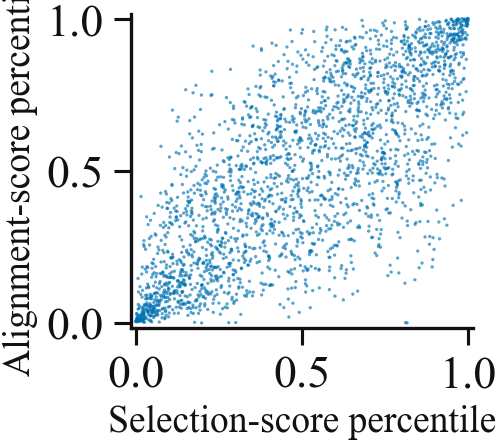

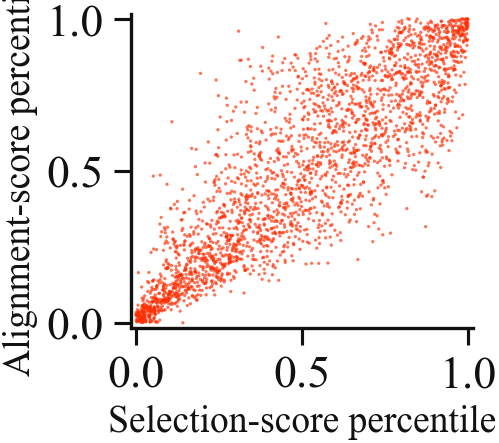

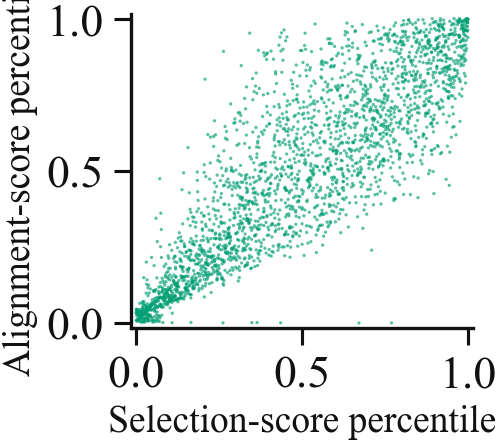

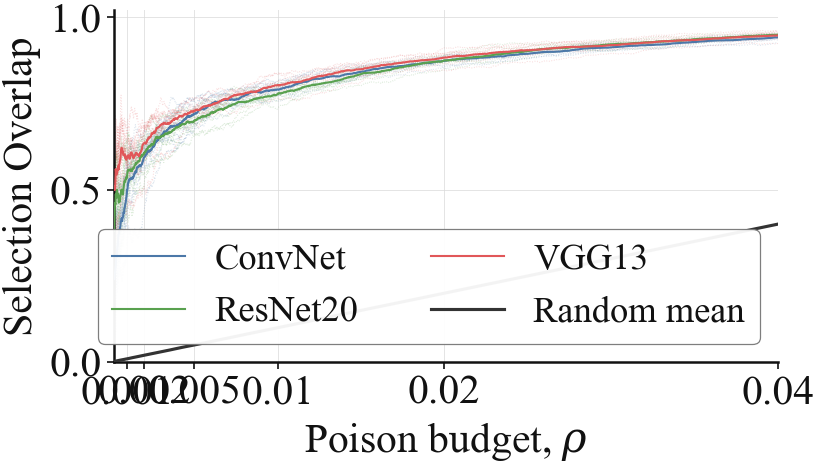

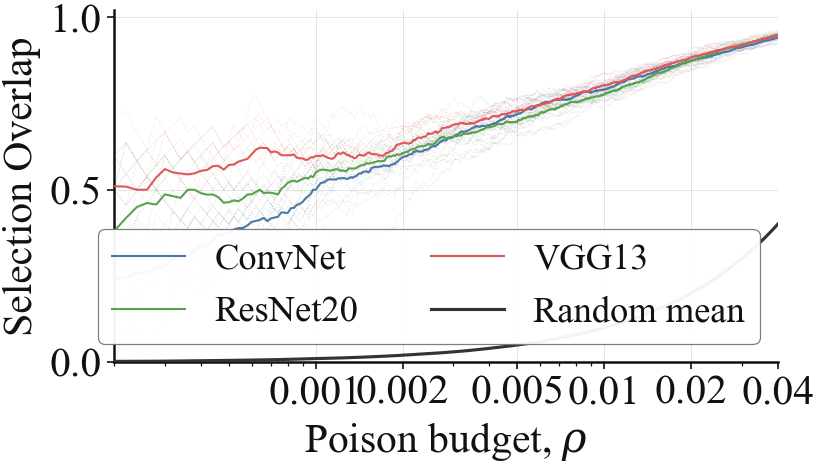

In [129]:
"""Jupyter-ready re-plotting of every experiment under scatter_result/.

Reads ONLY what final_update_scatter.py --scatter_mode saved (components.npz
and summary.json in each SCATTER_<run name>/ directory) and redraws the
figures from those arrays. Nothing is recomputed on a GPU, so every knob
below can be changed and the cell re-run in seconds.

Per experiment (one SCATTER_* directory) it can export:
  scatter_grid        raw x = rm, y = A for the saved random subset, one
                      panel per target
  rank_grid           the same subset as full-pool percentile ranks
  conditional_a       median A (with IQR band) in equal-count bins of x

Across all models selected by MODEL_FILTER it exports one combined
topk_overlap_linear figure and/or one combined topk_overlap_log figure. Each
model is represented by a thick mean curve and faint individual-target curves.

The two rankings compared by the overlap curve are defined by cheap_score()
and full_score() in USER CONTROLS, so the combination rule, the weight beta,
and the keep-lowest / keep-highest convention are all editable here.
"""

from pathlib import Path
import json
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import (
    FormatStrFormatter,
    LogFormatterMathtext,
    NullLocator,
    PercentFormatter,
)


# =============================================================================
# USER CONTROLS
# =============================================================================

RUN_SCATTER_GRID = False
RUN_CONDITIONAL = False


RUN_RANK_GRID = True
RUN_TOPK_LINEAR = True
RUN_TOPK_LOG = True
RUN_TOPK_LOG_Y = False

# Rank figures to export, keyed by (dataset, model). An empty mapping restores
# the default behavior of plotting every target selected by TARGET_FILTER.
RANK_TARGET_BY_DATASET_MODEL = {
    ("CIFAR10", "ConvNetBN"): 5705,
    ("CIFAR10", "ResNet20BN"): 6697,
    ("CIFAR10", "VGG13BN"): 2127,
}

# Where the SCATTER_* directories are, and which of them to plot. The filter
# is a tuple of substrings; an experiment is plotted when its directory name
# contains ANY of them. () plots everything.
RESULTS_ROOT = Path("scatter_result")
EXPERIMENT_FILTER = ()
# EXPERIMENT_FILTER = ("ConvNetBN_fc_ours_dog-bird",)

# Which datasets to plot, e.g. ("CIFAR100", "SVHN"). A directory name is
# SCATTER_<dataset>_<model>_..., so this matches the token right after
# SCATTER_. () plots every dataset found under RESULTS_ROOT.
DATASET_FILTER = ("CIFAR10",)
# DATASET_FILTER = ("CIFAR100",)

# Which models to plot, e.g. ("ConvNetBN", "ResNet20BN"). A directory name is
# SCATTER_<dataset>_<model>_..., so this matches the second token. () plots
# every model found under RESULTS_ROOT.
MODEL_FILTER = ("ConvNetBN", "ResNet20BN", "VGG13BN")
# MODEL_FILTER = ("ResNet20BN", "VGG13BN")

# Which targets to draw. () = every target saved in summary.json; otherwise a
# tuple of target indices, in the order they should appear.
TARGET_FILTER = ()

# Standard budgets marked on the overlap curve, as fractions of the training
# set (each becomes N_p = round(budget * N_total) on the x axis).
BUDGET_MARKS = (0.001,)
SHOW_BUDGET_MARKS = False
SHOW_BUDGET_MARK_VALUES = True
# The run's own N_p is always available as a mark as well.
SHOW_RUN_NP_MARK = True

# Empirical random baseline. Each trial draws random top-k subsets from the
# adversarial-class pool. The plot shows their mean and +/- one standard
# deviation; set SHOW_RANDOM_TRIALS=True to draw the individual trials too.
RANDOM_BASELINE_REPEATS = 100
RANDOM_BASELINE_SEED = 2026
SHOW_RANDOM_TRIALS = False
SHOW_RANDOM_STD_BAND = True

# Numeric plot-data cache. The first run writes reusable NPZ files; subsequent
# runs load them so visual-only tuning does not recompute ranks, overlaps, or
# the random baseline. Set REBUILD_PLOT_DATA_CACHE=True after changing score
# definitions, or increment PLOT_DATA_CACHE_VERSION for manual invalidation.
USE_PLOT_DATA_CACHE = True
SAVE_PLOT_DATA_CACHE = True
REBUILD_PLOT_DATA_CACHE = False
PLOT_DATA_CACHE_VERSION = 1
PLOT_DATA_ROOT = Path("figures/data/scatter")

# Overlap curve x range, as a fraction of the poison-class pool. Curves are
# evaluated over the full pool; these controls select the visible x range.
X_MAX_FRACTION = 0.04
# Linear version: left edge of the x axis. None means start at 0.
X_MIN_FRACTION = 0.0002
TOPK_X_TICKS = (0.001, 0.002, 0.005, 0.01, 0.02, 0.04)
TOPK_X_TICK_LABELS = (
    "0.001", "0.002", "0.005", "0.01", "0.02", "0.04",
)
# Log version: the smallest fraction shown (1 candidate = 1 / pool). None
# means start at the first candidate.
LOG_X_MIN_FRACTION = X_MIN_FRACTION

# Every x-axis value on the overlap plots (curves, budget marks, axis limits)
# is divided by this before plotting. Purely a display rescale: it only moves
# where things sit on the x axis, it does not change any plotted y-value or
# which k's are evaluated.
X_AXIS_DIVISOR = 10.0

# Conditional-A plot: number of equal-count bins of x.
CONDITIONAL_BINS = 20

# Scatter grid y axis: "linear" or "symlog". symlog keeps the bulk near 0
# readable while still showing the long positive tail of A.
SCATTER_Y_SCALE = "symlog"
SCATTER_SYMLOG_LINTHRESH = 0.5

# Panel grid shape for the per-target figures.
GRID_COLUMNS = 4


# -----------------------------------------------------------------------------
# The two rankings. Both are evaluated over the FULL poison-class pool of one
# target, with the arrays final_update_scatter.py's scatter_components() saved:
#   rm     = mean over surrogates of  std(d) - std(M),  d = 1 / ||f(x)-f(x_t)||^2
#   a      = mean over surrogates of  std(A)
# d_raw, m_raw, a_raw = the same three, NOT standardized. With d defined as a
# reciprocal squared distance, both rm and A are GAINS: larger is closer /
# more confident / more helpful, and the real selector keeps the LARGEST
# rm + beta * A (equivalently the smallest -rm - beta * A). This matches
# final_update_scatter.py's own topk_overlap curve exactly -- see its
# scatter_main(), which ranks by `-rm_np` (cheap) and `-rm_np - a_np` (full)
# and keeps the lowest of each; verified bit-for-bit against the
# topk_overlap_vs_full_score array it also saves into components.npz.
# KEEP_LOWEST = True  -> both functions return a COST and the k smallest win.
# KEEP_LOWEST = False -> both return a GAIN and the k largest win.
# -----------------------------------------------------------------------------

BETA = 1.0
KEEP_LOWEST = False


def cheap_score(rm, a, d_raw, m_raw, a_raw):
    """(R, M) ranking. Default: the saved gain rm = std(d) - std(M)."""
    return rm


def full_score(rm, a, d_raw, m_raw, a_raw):
    """(A, R, M) ranking. Default: rm + beta * A, the real selector."""
    return rm + BETA * a


# =============================================================================
# LABELS
# =============================================================================

SHOW_PANEL_TITLES = True

SCATTER_X_LABEL = r"$R_i + M_i$"
SCATTER_Y_LABEL = r"$A_i$"

RANK_X_LABEL = "Selection-score percentile"
RANK_Y_LABEL = "Alignment-score percentile"

CONDITIONAL_X_LABEL = "quantile of the (R, M) score  (0 = best)"
CONDITIONAL_Y_LABEL = r"median $A_i$ in bin"

TOPK_X_LABEL = r"Poison budget, $\rho$"
TOPK_Y_LABEL = r"Selection Overlap"

MODEL_LABELS = {
    "ConvNetBN": "ConvNet",
    "ResNet20BN": "ResNet20",
    "VGG13BN": "VGG13",
}
LEGEND_MODEL_LABEL = "{model}"
LEGEND_TARGET_LABEL = "Target runs"
LEGEND_RANDOM_LABEL = "Random mean"
LEGEND_RANDOM_STD_LABEL = r"Random $\pm$ 1 s.d."
LEGEND_IQR_LABEL = "inter-quartile band"

SHOW_STATS_BOX = True          # n / Pearson / Spearman box in scatter panels
STATS_BOX_FONT_SIZE = 7


# =============================================================================
# FIGURE STYLE
# =============================================================================

# All four exports use the same source size so they align cleanly when placed
# at equal widths in a one-row ICLR figure.
PANEL_SIZE = (3.375, 3.0)
SINGLE_FIG_SIZE = (5, 3.35)
FIGURE_DPI = 150

FONT_FAMILY = "serif"
SERIF_FONTS = (
    "Times New Roman",
    "Times",
    "Nimbus Roman No9 L",
    "DejaVu Serif",
)
MATH_FONTSET = "dejavuserif"

BASE_FONT_SIZE = 14
AXIS_LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 22
TITLE_FONT_SIZE = 18
PANEL_TITLE_FONT_SIZE = 16
LEGEND_FONT_SIZE = 11.5
ANNOTATION_FONT_SIZE = 11
TEXT_COLOR = "#111111"

SPINE_LINE_WIDTH = 1.6
MAJOR_TICK_LENGTH = 8.0
MAJOR_TICK_WIDTH = 1.5
TICK_LABEL_PAD = 5.0

SHOW_GRID = False
GRID_COLOR = "#D5D8DC"
GRID_LINE_WIDTH = 0.0
GRID_ALPHA = 0.0

# Marks
POINT_SIZE = 2.5
POINT_ALPHA = 0.65

MODEL_COLORS = {
    "ConvNetBN": "#0072B2",
    "ResNet20BN": "#FF2C00",
    "VGG13BN": "#009E73",
}
TOPK_MODEL_COLORS = {
    "ConvNetBN": "#4C78A8",
    "ResNet20BN": "#59A14F",
    "VGG13BN": "#E15759",
}
MEAN_LINE_STYLE = "-"
TARGET_LINE_STYLE = ":"
TARGET_LINE_WIDTH = 0.5
TARGET_LINE_ALPHA = 0.2
MEAN_LINE_WIDTH = 1
RANDOM_LINE_COLOR = "#8C8C8C"
RANDOM_LINE_WIDTH = 0.7
RANDOM_LINE_ALPHA = 0.22
RANDOM_MEAN_COLOR = "#333333"
RANDOM_MEAN_WIDTH = 1.5
RANDOM_STD_COLOR = "#A6A6A6"
RANDOM_STD_ALPHA = 0.28
IQR_FILL_COLOR = "#2a78d6"
IQR_FILL_ALPHA = 0.12

BUDGET_MARK_COLOR = "#B0B0B0"
BUDGET_MARK_WIDTH = 0.7
BUDGET_MARK_STYLE = "--"
BUDGET_MARK_TEXT_COLOR = "#555555"
BUDGET_MARK_TEXT_Y = 0.02       # axes fraction
RUN_NP_MARK_COLOR = "#E69F00"

ZERO_LINE_COLOR = "#B0B0B0"
ZERO_LINE_WIDTH = 0.8

# Overlap y axis
TOPK_Y_LIMITS = (0.0, 1.02)
TOPK_Y_TICKS = (0.0, 0.5, 1.0)
TOPK_Y_AS_PERCENT = False
TOPK_LOG_Y_LIMITS = (1e-3, 1.05)
TOPK_LOG_Y_TICKS = (1e-3, 1e-2, 1e-1, 1.0)

# TOPK-only presentation. These restore the earlier wide, lighter plot while
# leaving the three rank panels on the newer four-across paper style.
TOPK_AXIS_LABEL_FONT_SIZE = 20
TOPK_TICK_FONT_SIZE = 20
TOPK_LEGEND_FONT_SIZE = 17.5
TOPK_SPINE_LINE_WIDTH = 1.2
TOPK_MAJOR_TICK_LENGTH = 3.5
TOPK_MAJOR_TICK_WIDTH = 0.8
TOPK_TICK_LABEL_PAD = 2.5
TOPK_GRID_COLOR = "#D9D9D9"
TOPK_GRID_LINE_WIDTH = 0.45
TOPK_GRID_ALPHA = 0.75


# =============================================================================
# LEGEND AND EXPORT
# =============================================================================

SHOW_LEGEND = True
LEGEND_LOCATION = "lower left"
LEGEND_BBOX = None             # e.g. (0.98, 0.05); None = matplotlib default
LEGEND_FRAME_VISIBLE = True
LEGEND_BACKGROUND_COLOR = "white"
LEGEND_BACKGROUND_ALPHA = 0.95
LEGEND_BORDER_COLOR = "#777777"
LEGEND_BORDER_LINE_WIDTH = 1.0
LEGEND_NUMBER_OF_COLUMNS = 2

SAVE_PDF = True
SHOW_PLOTS = True
CLOSE_FIGURES_AFTER_SHOW = False

OUTPUT_ROOT_PDF = Path("figures/pdf/scatter")
OUTPUT_ROOT_PNG = Path("figures/png/scatter")
# SAVE_DPI = 300 /


# =============================================================================
# LOADING
# =============================================================================

def _configure_matplotlib():
    mpl.rcParams.update(
        {
            "figure.facecolor": "white",
            "figure.edgecolor": "white",
            "axes.facecolor": "white",
            "font.family": FONT_FAMILY,
            "font.serif": list(SERIF_FONTS),
            "font.size": BASE_FONT_SIZE,
            "text.color": TEXT_COLOR,
            "mathtext.fontset": MATH_FONTSET,
            "axes.labelcolor": TEXT_COLOR,
            "xtick.color": TEXT_COLOR,
            "ytick.color": TEXT_COLOR,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "savefig.dpi": SAVE_DPI,
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.transparent": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
        }
    )


def _discover_experiments():
    if not RESULTS_ROOT.is_dir():
        raise FileNotFoundError(f"{RESULTS_ROOT} does not exist")

    found = []
    for directory in sorted(RESULTS_ROOT.iterdir()):
        if not directory.is_dir() or not directory.name.startswith("SCATTER_"):
            continue
        if not (directory / "components.npz").is_file():
            print(f"skip {directory.name}: no components.npz")
            continue
        if not (directory / "summary.json").is_file():
            print(f"skip {directory.name}: no summary.json")
            continue
        if EXPERIMENT_FILTER and not any(
            token in directory.name for token in EXPERIMENT_FILTER
        ):
            continue
        if DATASET_FILTER:
            dataset = directory.name[len("SCATTER_"):].split("_", 1)[0]
            if dataset not in DATASET_FILTER:
                continue
        if MODEL_FILTER:
            model = directory.name[len("SCATTER_"):].split("_", 2)[1]
            if model not in MODEL_FILTER:
                continue
        found.append(directory)

    if not found:
        raise FileNotFoundError(
            f"no SCATTER_* experiment with components.npz under {RESULTS_ROOT}"
        )
    return found


class Experiment:
    """One SCATTER_* directory, loaded into plain numpy arrays."""

    def __init__(self, directory):
        self.directory = directory
        self.name = directory.name[len("SCATTER_"):]

        with open(directory / "summary.json") as handle:
            self.summary = json.load(handle)

        data = np.load(directory / "components.npz")
        self.pool_train_idx = data["pool_train_idx"]
        self.subset_pos = data["subset_pool_pos"]
        self.pool_size = int(len(self.pool_train_idx))

        summary_targets = [int(t) for t in self.summary["targets"]]
        component_targets = []
        for key in data.files:
            if not key.startswith("rm_target"):
                continue
            suffix = key[len("rm_target"):]
            if suffix.isdigit():
                component_targets.append(int(suffix))
        saved_targets = list(dict.fromkeys(summary_targets + component_targets))

        # Some result formats key component arrays by a compact target number
        # while storing the original CIFAR target ID in a parallel metadata
        # array. Accept either representation when selecting a rank target.
        self.target_alias_to_saved = {target: target for target in saved_targets}

        def register_target_aliases(name, values):
            if "target" not in name.lower():
                return
            try:
                aliases = np.asarray(values)
            except Exception:
                return
            if aliases.ndim != 1 or len(aliases) != len(summary_targets):
                return
            for saved_target, alias in zip(summary_targets, aliases):
                try:
                    self.target_alias_to_saved[int(alias)] = saved_target
                except (TypeError, ValueError):
                    continue

        for name, values in self.summary.items():
            register_target_aliases(name, values)
        for name in data.files:
            register_target_aliases(name, data[name])
        if TARGET_FILTER:
            missing = [t for t in TARGET_FILTER if t not in saved_targets]
            if missing:
                raise KeyError(
                    f"{self.name}: TARGET_FILTER has targets not in this run: "
                    f"{missing}"
                )
            self.targets = list(TARGET_FILTER)
        else:
            self.targets = saved_targets

        self.rm = {t: data[f"rm_target{t}"] for t in self.targets}
        self.a = {t: data[f"a_target{t}"] for t in self.targets}
        self.d_raw = {t: data[f"d_raw_target{t}"] for t in self.targets}
        self.m_raw = {t: data[f"m_raw_target{t}"] for t in self.targets}
        self.a_raw = {t: data[f"a_raw_target{t}"] for t in self.targets}

        self.model = self.summary.get("model", "?")
        self.dataset = self.name.split("_", 1)[0]
        self.attack = self.summary.get("attack", "?")
        self.class_pair = self.summary.get("class_pair", "?")
        self.budget = float(self.summary.get("budget") or 0.0)
        self.num_poisons = int(self.summary.get("num_poisons") or 0)

        # N_total is not stored; recover it from the run's own budget so the
        # standard budget marks land on the right N_p.
        if self.budget > 0 and self.num_poisons > 0:
            self.n_total = int(round(self.num_poisons / self.budget))
        else:
            self.n_total = None

    # --- derived quantities -------------------------------------------------

    def cheap(self, target):
        return np.asarray(
            cheap_score(self.rm[target], self.a[target], self.d_raw[target],
                        self.m_raw[target], self.a_raw[target]),
            dtype=np.float64,
        )

    def full(self, target):
        return np.asarray(
            full_score(self.rm[target], self.a[target], self.d_raw[target],
                       self.m_raw[target], self.a_raw[target]),
            dtype=np.float64,
        )

    def resolve_target(self, target):
        """Resolve an original dataset target ID to its saved component key."""
        return self.target_alias_to_saved.get(int(target))



    def budget_marks(self, k_max):
        """[(label, k, color)] for the dashed verticals of the overlap curve."""
        marks = []
        if SHOW_BUDGET_MARKS and self.n_total:
            for budget in BUDGET_MARKS:
                k = int(round(budget * self.n_total))
                if 1 <= k <= k_max:
                    marks.append((f"{budget:g}", k, BUDGET_MARK_COLOR))
        # if SHOW_RUN_NP_MARK and 1 <= self.num_poisons <= k_max:
        #     marks.append(("", 2000, RUN_NP_MARK_COLOR))
        return marks


# =============================================================================
# STATISTICS
# =============================================================================

def _pearson(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if len(x) < 2 or x.std() == 0 or y.std() == 0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def _rank(values):
    """0..1 percentile rank, 0 = smallest. Ties broken by position."""
    order = np.argsort(values, kind="stable")
    ranks = np.empty(len(values), dtype=np.float64)
    ranks[order] = np.arange(len(values))
    return ranks / max(len(values) - 1, 1)


def _spearman(x, y):
    try:
        from scipy.stats import spearmanr
        return float(spearmanr(x, y).correlation)
    except Exception:
        return _pearson(_rank(x), _rank(y))


def _best_first(score):
    """Indices ordered best first under the KEEP_LOWEST convention."""
    if KEEP_LOWEST:
        return np.argsort(score, kind="stable")
    return np.argsort(-score, kind="stable")


def _best_is_zero_rank(score):
    """Percentile rank with 0 = best under the KEEP_LOWEST convention."""
    return _rank(score) if KEEP_LOWEST else _rank(-score)


def _ordered_overlap_curve(order_left, order_right, ks):
    """Prefix-set overlap for two candidate orderings, computed in one sweep."""
    max_k = int(ks[-1])
    in_left = np.zeros(len(order_left), dtype=bool)
    in_right = np.zeros(len(order_right), dtype=bool)
    overlap = np.empty(max_k, dtype=np.float64)
    shared = 0

    for index in range(max_k):
        left = order_left[index]
        right = order_right[index]
        if in_right[left]:
            shared += 1
        in_left[left] = True
        if in_left[right] and not in_right[right]:
            shared += 1
        in_right[right] = True
        overlap[index] = shared / float(index + 1)

    return overlap[np.asarray(ks) - 1]


def _overlap_curve(cheap, full, ks):
    """|top-k by cheap intersect top-k by full| / k for every k in ks."""
    return _ordered_overlap_curve(_best_first(cheap), _best_first(full), ks)


# =============================================================================
# SHARED DRAWING
# =============================================================================

def _style_axes(ax):
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(TEXT_COLOR)
        ax.spines[side].set_linewidth(SPINE_LINE_WIDTH)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        axis="both", which="major", direction="out",
        length=MAJOR_TICK_LENGTH, width=MAJOR_TICK_WIDTH, pad=TICK_LABEL_PAD,
        labelsize=TICK_FONT_SIZE, color=TEXT_COLOR, labelcolor=TEXT_COLOR,
        top=False, right=False,
    )
    if SHOW_GRID:
        ax.grid(visible=True, which="major", color=GRID_COLOR,
                linewidth=GRID_LINE_WIDTH, alpha=GRID_ALPHA, zorder=0)
    else:
        ax.grid(visible=False)
    ax.set_axisbelow(True)


def _style_topk_axes(ax):
    """Restore the earlier lightweight TOPK axes without changing rank plots."""
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(TEXT_COLOR)
        ax.spines[side].set_linewidth(TOPK_SPINE_LINE_WIDTH)
    for side in ("right", "top"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        axis="both", which="major", direction="out",
        length=TOPK_MAJOR_TICK_LENGTH, width=TOPK_MAJOR_TICK_WIDTH,
        pad=TOPK_TICK_LABEL_PAD, labelsize=TOPK_TICK_FONT_SIZE,
        color=TEXT_COLOR, labelcolor=TEXT_COLOR, top=False, right=False,
    )
    ax.grid(
        visible=True, which="major", color=TOPK_GRID_COLOR,
        linewidth=TOPK_GRID_LINE_WIDTH, alpha=TOPK_GRID_ALPHA, zorder=0,
    )
    ax.set_axisbelow(True)


def _add_legend(ax):
    if not SHOW_LEGEND:
        return None
    kwargs = {
        "loc": LEGEND_LOCATION,
        "ncol": LEGEND_NUMBER_OF_COLUMNS,
        "frameon": LEGEND_FRAME_VISIBLE,
        "prop": {"size": LEGEND_FONT_SIZE},
    }
    if LEGEND_BBOX is not None:
        kwargs["bbox_to_anchor"] = LEGEND_BBOX
    legend = ax.legend(**kwargs)
    frame = legend.get_frame()
    frame.set_facecolor(LEGEND_BACKGROUND_COLOR)
    frame.set_alpha(LEGEND_BACKGROUND_ALPHA)
    frame.set_edgecolor(LEGEND_BORDER_COLOR)
    frame.set_linewidth(LEGEND_BORDER_LINE_WIDTH)
    return legend


def _add_topk_legend(ax):
    """Compact legend used by the restored TOPK layout."""
    if not SHOW_LEGEND:
        return None
    legend = ax.legend(
        loc="lower right", ncol=2, frameon=LEGEND_FRAME_VISIBLE,
        prop={"size": TOPK_LEGEND_FONT_SIZE},
    )
    frame = legend.get_frame()
    frame.set_facecolor(LEGEND_BACKGROUND_COLOR)
    frame.set_alpha(LEGEND_BACKGROUND_ALPHA)
    frame.set_edgecolor(LEGEND_BORDER_COLOR)
    frame.set_linewidth(0.6)
    return legend


def _stats_box(ax, x, y):
    if not SHOW_STATS_BOX:
        return
    ax.text(
        0.03, 0.97,
        f"n = {len(x)}\nPearson = {_pearson(x, y):.3f}\n"
        f"Spearman = {_spearman(x, y):.3f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=STATS_BOX_FONT_SIZE,
        bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#CCCCCC",
              "boxstyle": "round,pad=0.35"},
    )


def _grid(n_panels):
    columns = max(1, min(GRID_COLUMNS, n_panels))
    rows = int(math.ceil(n_panels / float(columns)))
    fig, axes = plt.subplots(
        rows, columns,
        figsize=(PANEL_SIZE[0] * columns, PANEL_SIZE[1] * rows),
        dpi=FIGURE_DPI, squeeze=False, constrained_layout=True,
    )
    for index in range(n_panels, rows * columns):
        axes[index // columns][index % columns].set_axis_off()
    return fig, axes, rows, columns


def _save(fig, experiment, stem):
    common = {
        "dpi": 500, "bbox_inches": None, "pad_inches": 0.0,
        "facecolor": "white", "edgecolor": "white", "transparent": False,
    }
    if SAVE_PDF:
        destination = '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter'
        # destination.mkdir(parents=True, exist_ok=True)
        fig.savefig( '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter' +f"{stem}.pdf", **common)
        # print(f"wrote {destination / f'{stem}.pdf'}")


def _save_combined(fig, stem):
    """Save a figure that combines every model selected for this invocation."""
    common = {
        "dpi": SAVE_DPI, "bbox_inches": "tight", "pad_inches": 0.02,
        "facecolor": "white", "edgecolor": "white", "transparent": False,
    }
    if SAVE_PDF:
        OUTPUT_ROOT_PDF.mkdir(parents=True, exist_ok=True)
        destination = '/Users/mohammad/Downloads/PoisonBase/figures/pdf/scatter'+ f"{stem}.pdf"
        fig.savefig(destination, **common)
        print(f"wrote {destination}")


def _experiment_source_state(experiment):
    """Stable cache inputs for one experiment's saved numeric artifacts."""
    sources = []
    for filename in ("components.npz", "summary.json"):
        path = experiment.directory / filename
        stat = path.stat()
        sources.append({
            "name": filename,
            "size": stat.st_size,
            "mtime_ns": stat.st_mtime_ns,
        })
    return {
        "name": experiment.name,
        "targets": list(experiment.targets),
        "pool_size": experiment.pool_size,
        "sources": sources,
    }


def _cache_metadata(kind, experiments, **extra):
    metadata = {
        "version": PLOT_DATA_CACHE_VERSION,
        "kind": kind,
        "beta": BETA,
        "keep_lowest": KEEP_LOWEST,
        "experiments": [
            _experiment_source_state(experiment) for experiment in experiments
        ],
    }
    metadata.update(extra)
    return metadata


def _metadata_json(metadata):
    return json.dumps(metadata, sort_keys=True, separators=(",", ":"))


def _load_plot_data(path, metadata):
    if (not USE_PLOT_DATA_CACHE or REBUILD_PLOT_DATA_CACHE
            or not path.is_file()):
        return None
    try:
        with np.load(path, allow_pickle=False) as cached:
            if str(cached["metadata_json"].item()) != _metadata_json(metadata):
                return None
            arrays = {
                name: cached[name].copy()
                for name in cached.files
                if name != "metadata_json"
            }
    except (OSError, KeyError, ValueError):
        return None
    # print(f"loaded plot data {path}")
    return arrays


def _save_plot_data(path, metadata, **arrays):
    if not SAVE_PLOT_DATA_CACHE:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        path,
        metadata_json=np.asarray(_metadata_json(metadata)),
        **arrays,
    )
    print(f"saved plot data {path}")


def _rank_plot_data(experiment, target):
    """Load or compute the exact x/y arrays used by one rank figure."""
    cache_path = (
        PLOT_DATA_ROOT / experiment.name / f"rank_target{target}.npz"
    )
    metadata = _cache_metadata(
        "rank", [experiment], saved_target=int(target)
    )
    cached = _load_plot_data(cache_path, metadata)
    if cached is not None:
        return (
            cached["displayed_x"], cached["y"],
            float(cached["pearson"].item()),
        )

    subset = experiment.subset_pos
    x = _best_is_zero_rank(experiment.cheap(target))[subset]
    y = _rank(experiment.a[target])[subset]
    displayed_x = 1.0 - x
    pearson = _pearson(displayed_x, y)
    _save_plot_data(
        cache_path, metadata, displayed_x=displayed_x, y=y,
        pearson=np.asarray(pearson),
    )
    return displayed_x, y, pearson



# =============================================================================
# FIGURE 2: rank-rank plots (saved random subset, full-pool ranks)
#           one separate figure per target, not a shared grid
# =============================================================================

def plot_rank_grid(experiment):
    if RANK_TARGET_BY_DATASET_MODEL:
        requested_target = RANK_TARGET_BY_DATASET_MODEL.get(
            (experiment.dataset, experiment.model)
        )
        if requested_target is None:
            return {}
        target = experiment.resolve_target(requested_target)
        if target is None or target not in experiment.targets:
            # Several runs can share the same dataset/model. Only the run that
            # actually saved this requested target should produce a rank plot.
            return {}
        rank_targets = ((requested_target, target),)
    else:
        rank_targets = tuple((target, target) for target in experiment.targets)

    model_color = _model_color(experiment.model)

    figs = {}
    for output_target, target in rank_targets:
        fig, ax = plt.subplots(figsize=PANEL_SIZE, dpi=FIGURE_DPI,
                               constrained_layout=True)
        displayed_x, y, pearson = _rank_plot_data(experiment, target)

        ax.scatter(displayed_x, y, s=POINT_SIZE, alpha=POINT_ALPHA,
                   color=model_color,
                   edgecolors="none", rasterized=True, zorder=3)
        # Keep boundary markers fully visible while retaining rank ticks at
        # their meaningful 0--1 values.
        ax.set_xlim(-0.015, 1.015)
        ax.set_ylim(-0.015, 1.015)
        ax.set_xticks((0.0, 0.5, 1.0))
        ax.set_yticks((0.0, 0.5, 1.0))
        _style_axes(ax)
        ax.set_ylabel(RANK_Y_LABEL, fontsize=AXIS_LABEL_FONT_SIZE)
        ax.set_xlabel(RANK_X_LABEL, fontsize=AXIS_LABEL_FONT_SIZE)

        _save(
            fig, experiment,
            f"rank_target{output_target}_pearson_{pearson:+.3f}",
        )
        figs[output_target] = fig
    return figs




# =============================================================================
# FIGURE 4 / 5: overlap of the (R,M) and (A,R,M) selections
# =============================================================================

def _overlap_curves(experiment):
    cache_path = (
        PLOT_DATA_ROOT / experiment.name / "topk_overlap_curves.npz"
    )
    metadata = _cache_metadata("topk_overlap", [experiment])
    cached = _load_plot_data(cache_path, metadata)
    if cached is not None:
        return cached["ks"], [curve for curve in cached["curves"]]

    k_max = int(round( experiment.pool_size))
    k_max = max(1, min(k_max, experiment.pool_size))
    ks = np.arange(1, k_max + 1)
    curves = [
        _overlap_curve(experiment.cheap(target), experiment.full(target), ks)
        for target in experiment.targets
    ]
    _save_plot_data(cache_path, metadata, ks=ks, curves=np.stack(curves))
    return ks, curves


def _random_cache_metadata(experiments):
    return _cache_metadata(
        "topk_random", experiments,
        repeats=RANDOM_BASELINE_REPEATS,
        seed=RANDOM_BASELINE_SEED,
    )


def _load_random_plot_data(experiments):
    cache_path = PLOT_DATA_ROOT / "topk_random_trials.npz"
    metadata = _random_cache_metadata(experiments)
    cached = _load_plot_data(cache_path, metadata)
    if cached is None:
        return None
    return [
        (cached["fraction"], curve)
        for curve in cached["trial_means"]
    ]


def _save_random_plot_data(experiments, trial_means):
    cache_path = PLOT_DATA_ROOT / "topk_random_trials.npz"
    metadata = _random_cache_metadata(experiments)
    fraction = trial_means[0][0]
    curves = np.stack([curve for _, curve in trial_means])
    _save_plot_data(
        cache_path, metadata, fraction=fraction, trial_means=curves,
    )


def _ordered_model_groups(experiments):
    """Return (model, experiments) groups in MODEL_FILTER order."""
    grouped = {}
    for experiment in experiments:
        grouped.setdefault(experiment.model, []).append(experiment)

    requested = ((MODEL_FILTER,) if isinstance(MODEL_FILTER, str)
                 else tuple(MODEL_FILTER))
    ordered_models = [model for model in requested if model in grouped]
    ordered_models.extend(model for model in grouped if model not in ordered_models)
    if len(ordered_models) > len(MODEL_COLORS):
        raise ValueError(
            f"selected {len(ordered_models)} models but only "
            f"{len(MODEL_COLORS)} publication colors are configured"
        )
    return [(model, grouped[model]) for model in ordered_models]


def _model_color(model):
    """Use the same model-to-color assignment in rank and TOPK figures."""
    if model not in MODEL_COLORS:
        raise KeyError(f"no publication color configured for model {model!r}")
    return MODEL_COLORS[model]


def _topk_model_color(model):
    if model not in TOPK_MODEL_COLORS:
        raise KeyError(f"no TOPK color configured for model {model!r}")
    return TOPK_MODEL_COLORS[model]


def _stack_on_common_x(curves):
    """Stack (x, y) curves, interpolating only when x grids differ."""
    reference_x = curves[0][0]
    if all(len(x) == len(reference_x) and np.array_equal(x, reference_x)
           for x, _ in curves[1:]):
        return reference_x, np.stack([y for _, y in curves])

    lower = max(x[0] for x, _ in curves)
    upper = min(x[-1] for x, _ in curves)
    reference_x = max(curves, key=lambda item: len(item[0]))[0]
    common_x = reference_x[(reference_x >= lower) & (reference_x <= upper)]
    interpolated = [np.interp(common_x, x, y) for x, y in curves]
    return common_x, np.stack(interpolated)


def _mean_on_common_x(curves):
    """Average (x, y) curves on a shared x grid."""
    common_x, stacked = _stack_on_common_x(curves)
    return common_x, np.mean(stacked, axis=0)


def plot_topk(experiments, log_x=False, log_y=False):
    if log_x and log_y:
        raise ValueError("TOPK supports one logarithmic axis at a time")

    fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE, dpi=FIGURE_DPI)
    fig.subplots_adjust(left=0.10, right=0.985, bottom=0.27, top=0.97)

    random_trial_fraction_means = _load_random_plot_data(experiments)
    if random_trial_fraction_means is None:
        rng = np.random.default_rng(RANDOM_BASELINE_SEED)
        random_trials = [[] for _ in range(RANDOM_BASELINE_REPEATS)]
    else:
        rng = None
        random_trials = None
    minimum_x = float("inf")
    maximum_x = 0.0
    for model_index, (model, model_experiments) in enumerate(
            _ordered_model_groups(experiments)):
        color = _topk_model_color(model)
        model_curves = []

        for experiment in model_experiments:
            ks, curves = _overlap_curves(experiment)
            fraction = ks / float(experiment.pool_size)
            x_axis = fraction / X_AXIS_DIVISOR
            minimum_x = min(minimum_x, float(x_axis[0]))
            maximum_x = max(maximum_x, float(x_axis[-1]))
            for target, curve in zip(experiment.targets, curves):
                model_curves.append((x_axis, curve))
                ax.plot(
                    x_axis, curve, color=color, linestyle=TARGET_LINE_STYLE,
                    alpha=TARGET_LINE_ALPHA, linewidth=TARGET_LINE_WIDTH,
                    zorder=2,
                )

                if random_trials is not None:
                    full_order = _best_first(experiment.full(target))
                    for trial in random_trials:
                        random_order = rng.permutation(experiment.pool_size)
                        random_curve = _ordered_overlap_curve(
                            full_order, random_order, ks
                        )
                        # Cache the true pool fraction. X_AXIS_DIVISOR is a
                        # display control and must remain freely tunable.
                        trial.append((fraction, random_curve))

        mean_x, mean = _mean_on_common_x(model_curves)
        ax.plot(
            mean_x, mean, color=color, linestyle=MEAN_LINE_STYLE,
            linewidth=MEAN_LINE_WIDTH,
            label=LEGEND_MODEL_LABEL.format(
                model=MODEL_LABELS.get(model, model), n=len(model_curves)
            ),
            zorder=4,
        )

    if random_trial_fraction_means is None:
        random_trial_fraction_means = []
        for trial in random_trials:
            trial_fraction, trial_mean = _mean_on_common_x(trial)
            random_trial_fraction_means.append((trial_fraction, trial_mean))
        _save_random_plot_data(experiments, random_trial_fraction_means)

    random_trial_means = [
        (fraction / X_AXIS_DIVISOR, curve)
        for fraction, curve in random_trial_fraction_means
    ]
    for trial_x, trial_mean in random_trial_means:
        if SHOW_RANDOM_TRIALS:
            ax.plot(
                trial_x, trial_mean, color=RANDOM_LINE_COLOR,
                linestyle=TARGET_LINE_STYLE, linewidth=RANDOM_LINE_WIDTH,
                alpha=RANDOM_LINE_ALPHA, zorder=1,
            )

    random_mean_x, random_stack = _stack_on_common_x(random_trial_means)
    random_mean = np.mean(random_stack, axis=0)
    random_std = np.std(
        random_stack, axis=0, ddof=1 if RANDOM_BASELINE_REPEATS > 1 else 0
    )
    if SHOW_RANDOM_STD_BAND:
        random_band_floor = TOPK_LOG_Y_LIMITS[0] if log_y else 0.0
        ax.fill_between(
            random_mean_x,
            np.clip(random_mean - random_std, random_band_floor, 1.0),
            np.clip(random_mean + random_std, 0.0, 1.0),
            color=RANDOM_STD_COLOR, alpha=RANDOM_STD_ALPHA, linewidth=0,
            zorder=1,
        )
    ax.plot(
        random_mean_x, random_mean, color=RANDOM_MEAN_COLOR,
        linestyle=MEAN_LINE_STYLE, linewidth=RANDOM_MEAN_WIDTH,
        label=LEGEND_RANDOM_LABEL.format(n=RANDOM_BASELINE_REPEATS), zorder=3,
    )

    seen_marks = set()
    for experiment in experiments:
        for label, k, color in experiment.budget_marks(experiment.pool_size):
            x = (k / float(experiment.pool_size)) / X_AXIS_DIVISOR
            mark_key = (label, round(x, 12))
            if mark_key in seen_marks:
                continue
            seen_marks.add(mark_key)
            ax.axvline(x, color=color, linewidth=BUDGET_MARK_WIDTH,
                       linestyle=BUDGET_MARK_STYLE, zorder=1)
            if SHOW_BUDGET_MARK_VALUES:
                ax.text(
                    x, BUDGET_MARK_TEXT_Y, label,
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=ANNOTATION_FONT_SIZE, color=BUDGET_MARK_TEXT_COLOR,
                )

    if log_x:
        ax.set_xscale("log")
        x_min = (LOG_X_MIN_FRACTION if LOG_X_MIN_FRACTION is not None
                 else minimum_x)
        x_max = X_MAX_FRACTION if X_MAX_FRACTION is not None else maximum_x
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(TOPK_X_TICKS)
        ax.set_xticklabels(
            TOPK_X_TICK_LABELS, rotation=0, ha="center", va="top"
        )
    else:
        x_min = X_MIN_FRACTION if X_MIN_FRACTION is not None else 0.0
        x_max = X_MAX_FRACTION if X_MAX_FRACTION is not None else 0.0
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(TOPK_X_TICKS)
        ax.set_xticklabels(
            TOPK_X_TICK_LABELS, rotation=0, ha="center", va="top"
        )

    if log_y:
        ax.set_yscale("log")
        ax.set_ylim(*TOPK_LOG_Y_LIMITS)
        ax.set_yticks(TOPK_LOG_Y_TICKS)
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
    else:
        ax.set_ylim(*TOPK_Y_LIMITS)
        ax.set_yticks(TOPK_Y_TICKS)
        if TOPK_Y_AS_PERCENT:
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_minor_locator(NullLocator())

    _style_topk_axes(ax)
    ax.set_xlabel(TOPK_X_LABEL, fontsize=TOPK_AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(TOPK_Y_LABEL, fontsize=TOPK_AXIS_LABEL_FONT_SIZE)
    _add_topk_legend(ax)
    if log_x:
        stem = "topk_overlap_log"
    elif log_y:
        stem = "topk_overlap_log_y"
    else:
        stem = "topk_overlap_linear"
    _save_combined(fig, stem)
    return fig


# =============================================================================
# JUPYTER EXECUTION
# =============================================================================

_configure_matplotlib()

_experiments = [Experiment(directory) for directory in _discover_experiments()]
all_figures = {}
for _experiment in _experiments:
    print(f"=== {_experiment.name}: pool {_experiment.pool_size}, "
          f"N_p {_experiment.num_poisons}, targets {_experiment.targets}")
    _figs = {}
    if RUN_RANK_GRID:
        for _target, _fig in plot_rank_grid(_experiment).items():
            _figs[f"rank_target{_target}"] = _fig
    all_figures[_experiment.name] = _figs

_topk_figs = {}
if RUN_TOPK_LINEAR:
    _topk_figs["topk_overlap_linear"] = plot_topk(_experiments, log_x=False)
if RUN_TOPK_LOG:
    _topk_figs["topk_overlap_log"] = plot_topk(_experiments, log_x=True)
if RUN_TOPK_LOG_Y:
    _topk_figs["topk_overlap_log_y"] = plot_topk(_experiments, log_y=True)
if _topk_figs:
    all_figures["combined_models"] = _topk_figs

if SHOW_PLOTS:
    plt.show()

if CLOSE_FIGURES_AFTER_SHOW:
    for _figs in all_figures.values():
        for _fig in _figs.values():
            plt.close(_fig)


# Defense

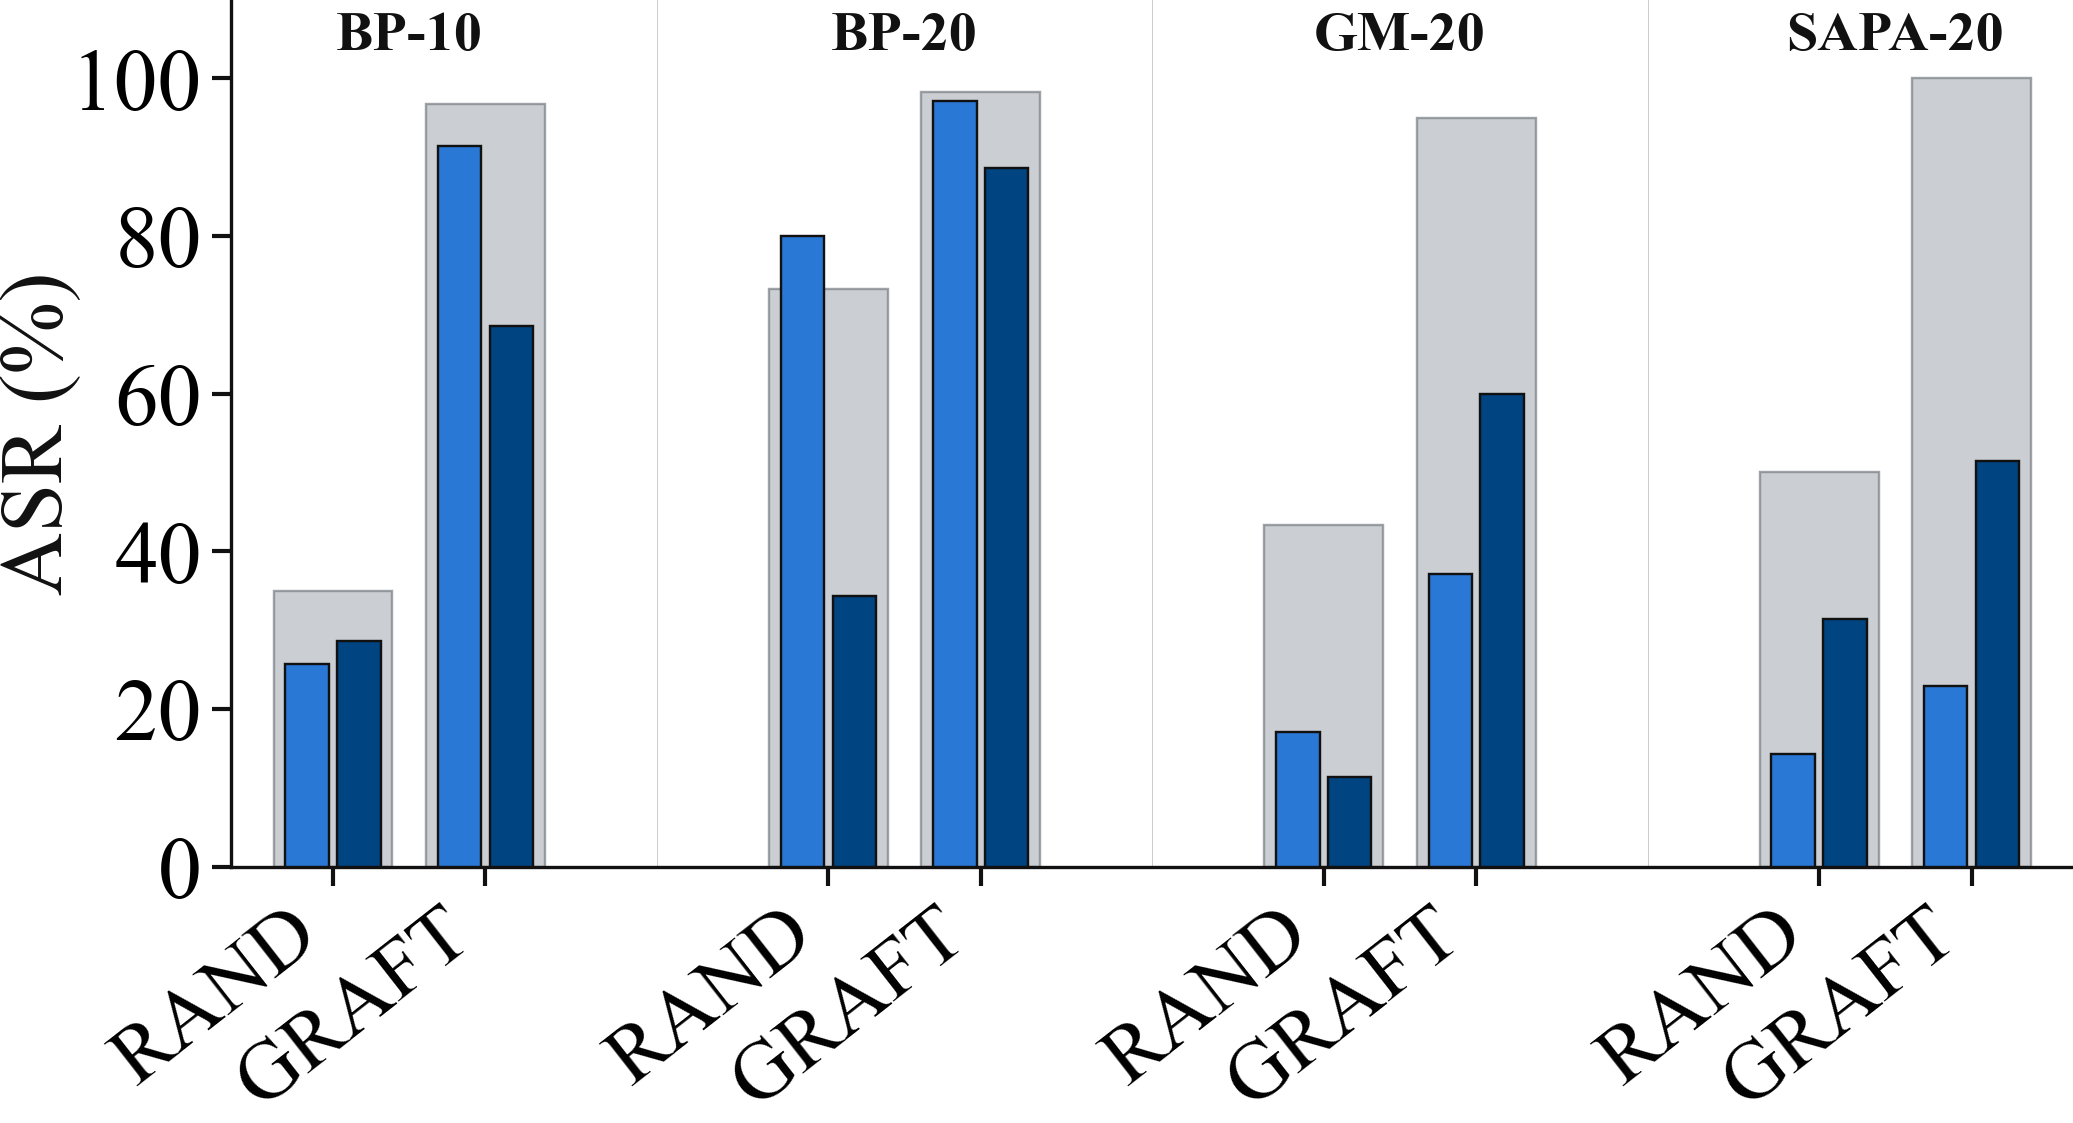

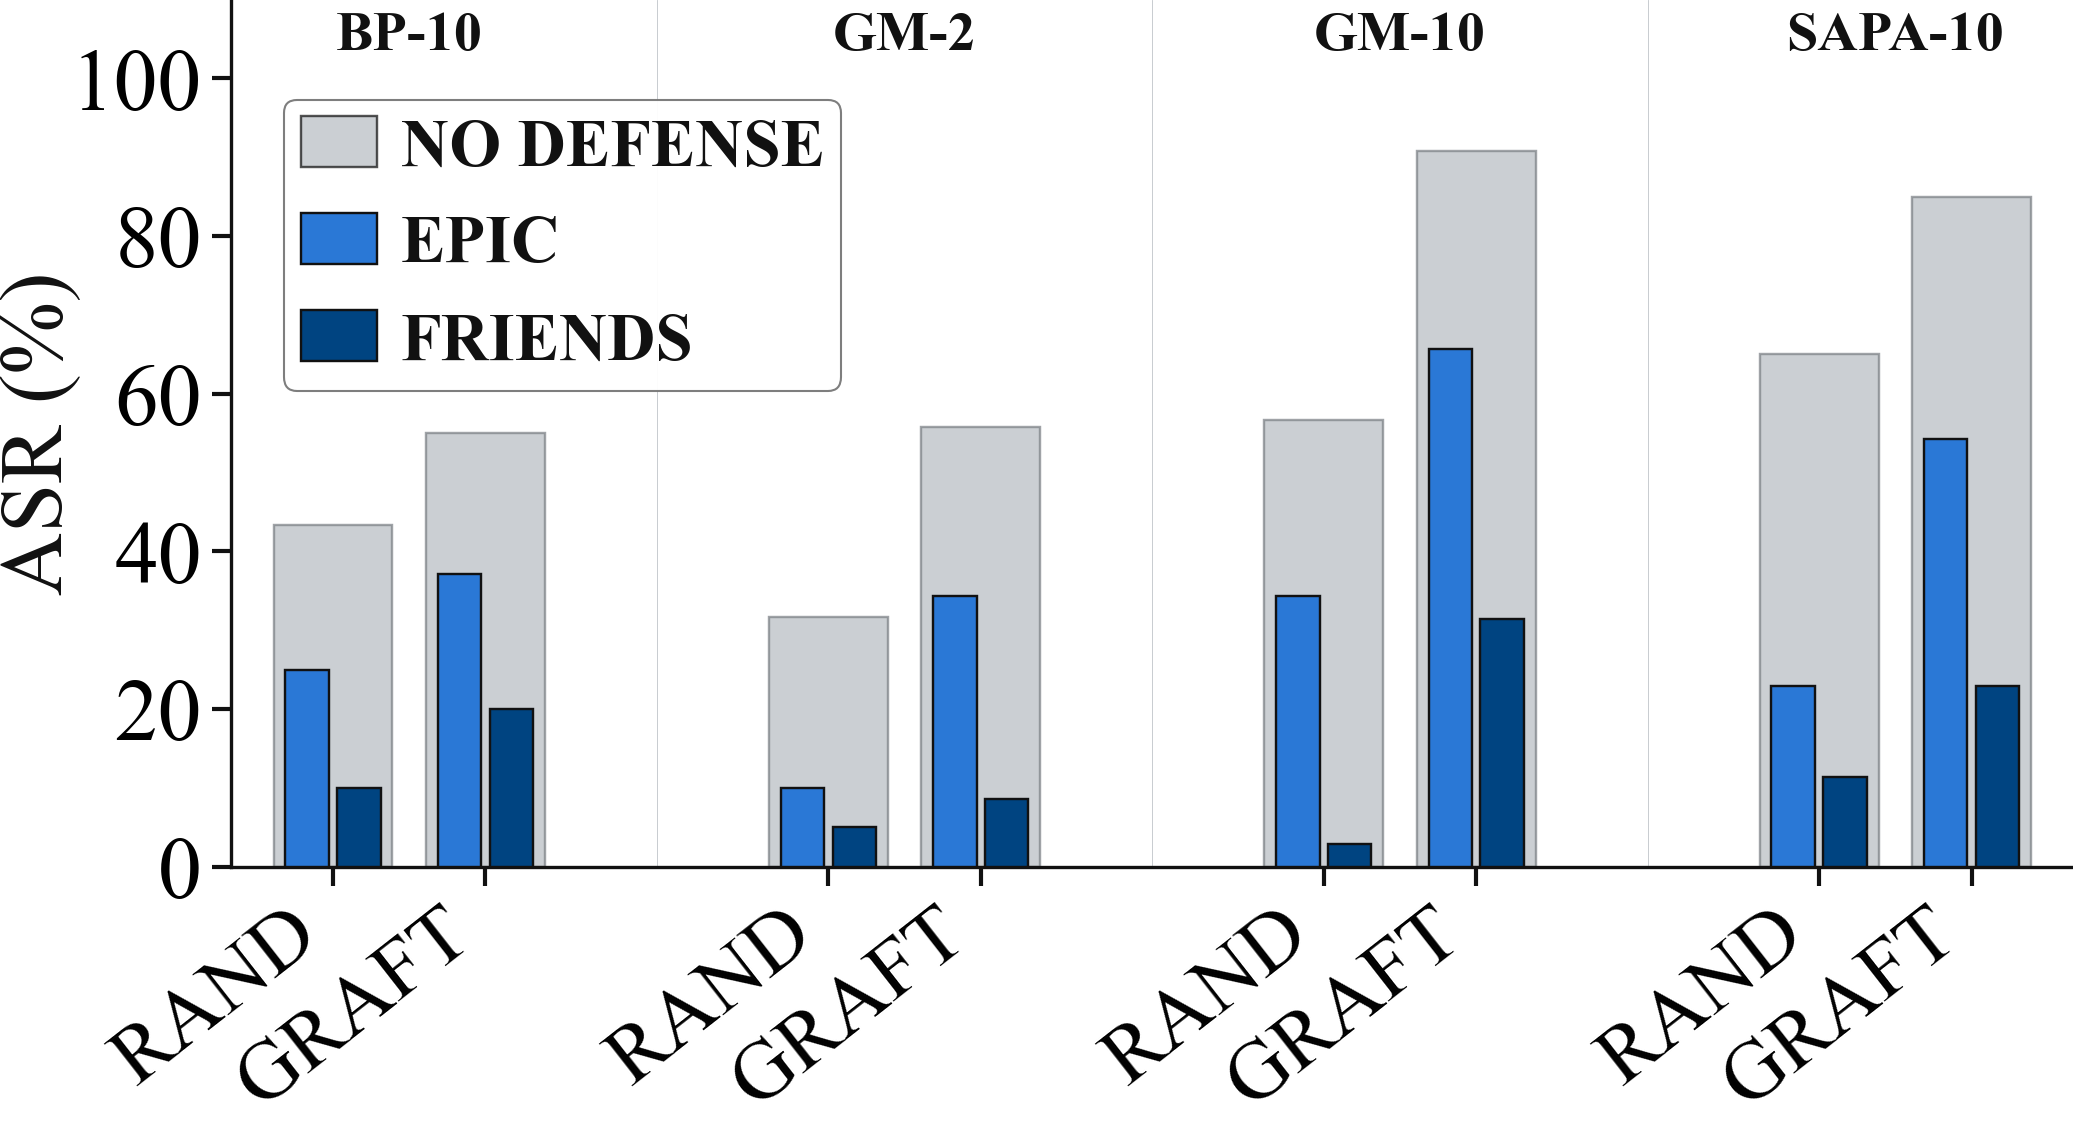

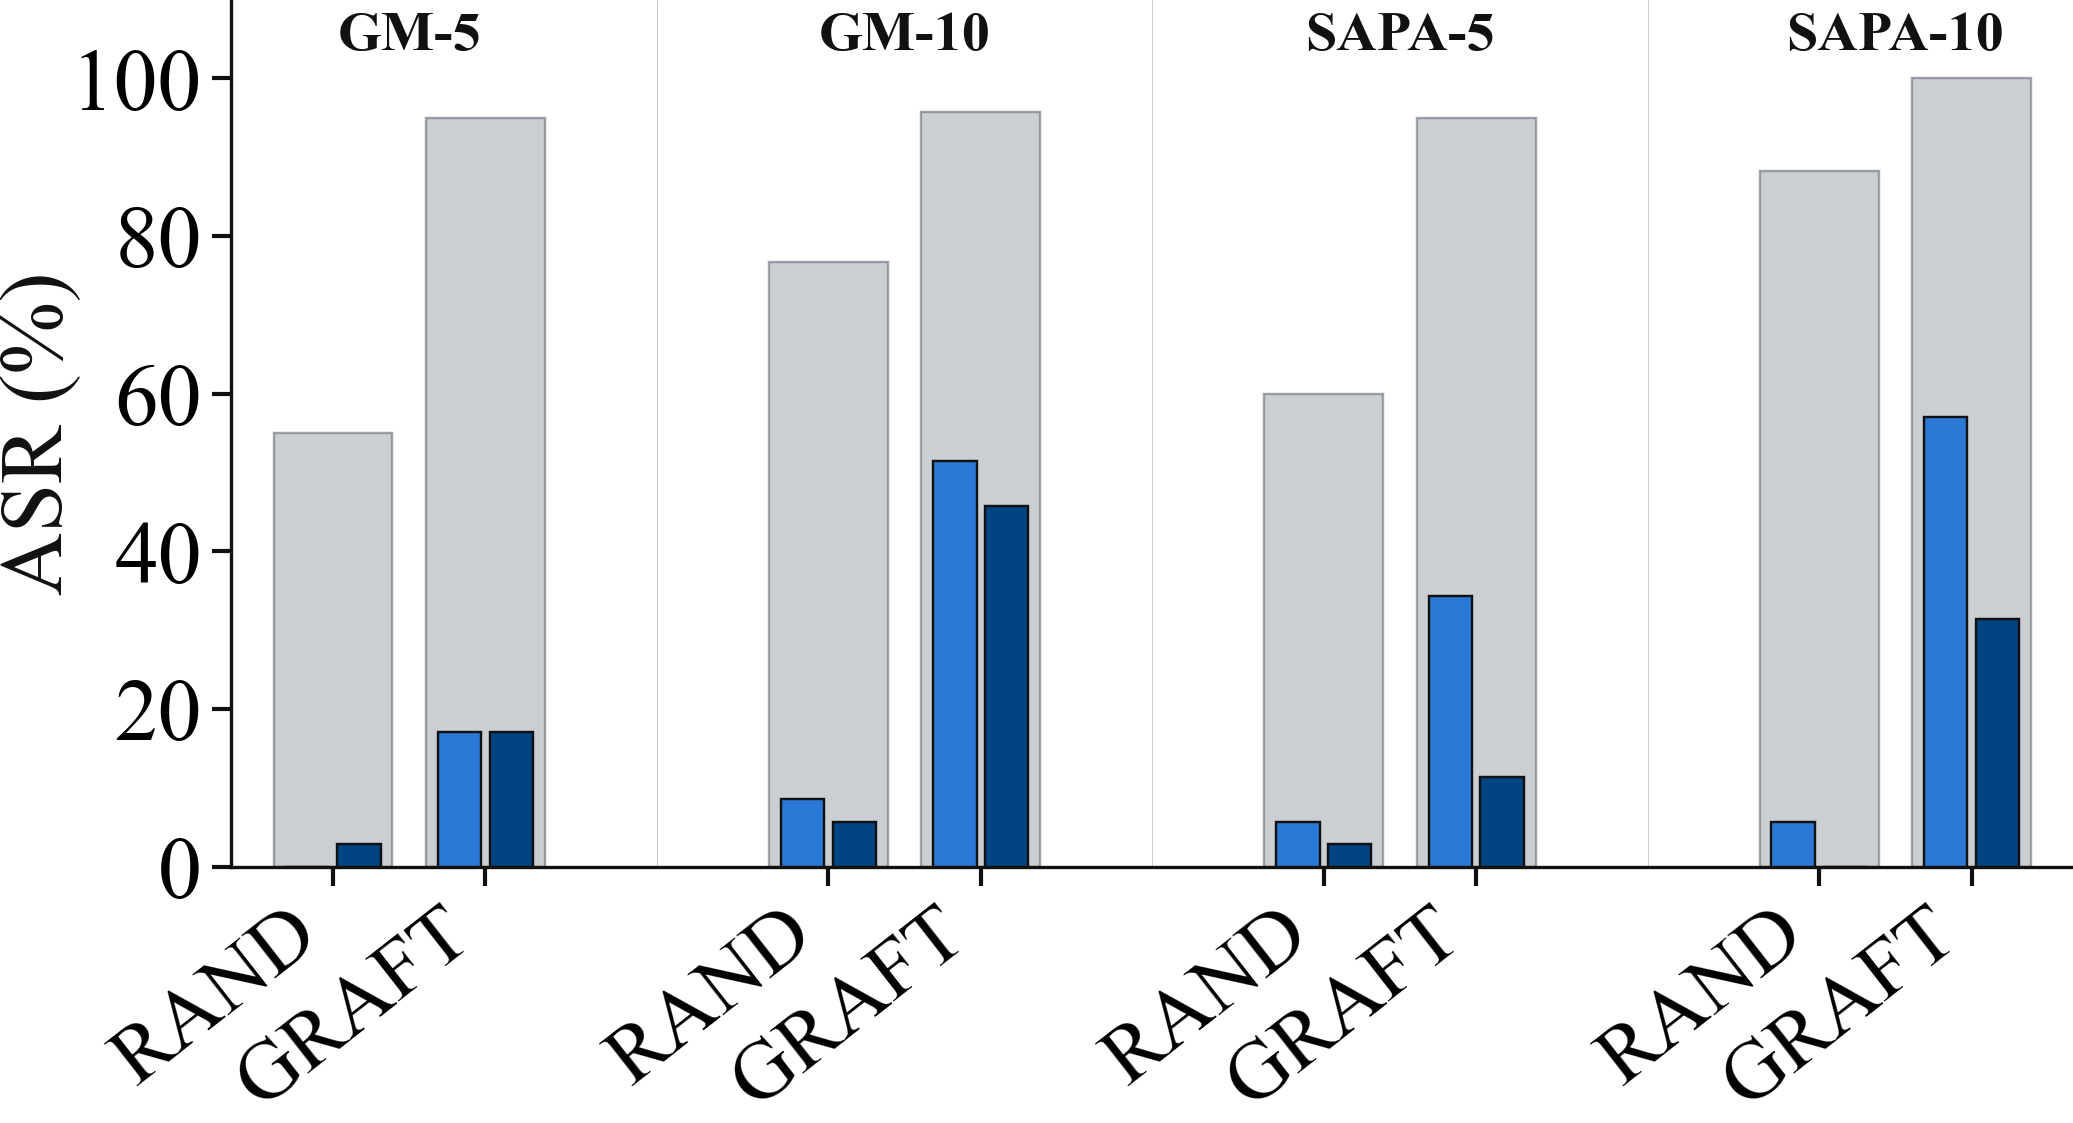

In [130]:
"""Three Jupyter-ready layouts for the defense experiment.

Each layout exports one independent PDF for ConvNet, ResNet-20, and VGG-13.
Every architecture keeps its four configurations separate and includes RAND,
GRAFT, GRAFT+, DPP, and DPP_J under no defense, EPIC, and FRIENDS.
"""

from pathlib import Path
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter, NullLocator


# =============================================================================
# USER CONTROLS
# =============================================================================

RUN_VERSION_1 = False   # selectors on x axis, three defense bars per selector
RUN_VERSION_2 = False   # defenses on x axis, five selector bars per defense
RUN_VERSION_3 = True   # no-defense background with EPIC and FRIENDS in front

MODEL_ORDER = ("ConvNet", "ResNet20", "VGG13")
# METHOD_ORDER = ("random", "graft", "graft_plus", "dpp", "dpp_j")
# METHOD_ORDER = ("random", "graft", "graft_plus")
METHOD_ORDER = ("random", "graft")
CONDITION_ORDER = ("no_defense", "epic", "friends")

# These tuples are active selectors. Data/style dictionaries are allowed to
# contain additional entries; only names selected here are validated/plotted.

# ASR rows are stored in this fixed positional order. Do not change this tuple
# when hiding or reordering methods; edit METHOD_ORDER above instead.
# DATA_METHOD_ORDER = ("random", "graft", "graft_plus", "dpp", "dpp_j")
DATA_METHOD_ORDER = ("random", "graft", "graft_plus", "dpp", "dpp_j")
METHOD_DATA_INDEX = {
    method: index for index, method in enumerate(DATA_METHOD_ORDER)
}

# Group-heading placement and background bands.
GROUP_LABEL_INSIDE_TOP_Y = 0.985
GROUP_LABEL_VERTICAL_ALIGNMENT = "top"
GROUP_LABEL_CLIP_ON = True
SHOW_GROUP_BACKGROUND_SHADING = False
GROUP_BACKGROUND_MAX_ZORDER = 1

# Shared legend layout for every plot version.
LEGEND_NUMBER_OF_COLUMNS = 1

# Legend frame, background, and internal spacing controls.
LEGEND_FRAME_VISIBLE = True
LEGEND_BACKGROUND_COLOR = "white"
LEGEND_BACKGROUND_ALPHA = 0.95
LEGEND_BORDER_COLOR = "#777777"
LEGEND_BORDER_LINE_WIDTH = 1.0
LEGEND_BORDER_LINE_STYLE = "-"
LEGEND_BOX_STYLE = "round,pad=0.0,rounding_size=0.2"
LEGEND_BORDER_PAD = 0.40
LEGEND_BORDER_AXES_PAD = 0.20
LEGEND_COLUMN_SPACING = 1.25
LEGEND_ROW_SPACING = 0.35
LEGEND_HANDLE_TEXT_PAD = 0.55
LEGEND_HANDLE_LENGTH = 1.50
LEGEND_HANDLE_HEIGHT = 0.70
LEGEND_MARKER_SCALE = 1.0
LEGEND_MARKER_FIRST = True
LEGEND_ALIGNMENT = "center"
LEGEND_ZORDER = 30

# Distance, in points, between the y-axis tick area and its label/title.
Y_LABEL_PAD = -5.0

MODEL_SLUGS = {
    "ConvNet": "convnet",
    "ResNet20": "resnet20",
    "VGG13": "vgg13",
}

CONFIGURATION_ORDER = {
    "ConvNet": ("BP-10", "BP-20", "GM-20", "SAPA-20"),
    "ResNet20": ("BP-10", "GM-2", "GM-10", "SAPA-10"),
    "VGG13": ("GM-5", "GM-10", "SAPA-5", "SAPA-10"),
}

METHOD_LABELS = {
    "random": "RAND",
    "graft": "GRAFT",
    "graft_plus": r"GRAFT$^{+}$",
    "dpp": "DPP",
    "dpp_j": r"DPP$_J$",
}

# Axis-only display aliases. The underlying method/data key remains unchanged.
X_AXIS_METHOD_LABEL_ALIASES = {
    "graft_plus": "GRAFT",
}

CONDITION_LABELS = {
    "no_defense": "NO DEFENSE",
    "epic": "EPIC",
    "friends": "FRIENDS",
}

CONDITION_TICK_LABELS = {
    "no_defense": "No def.",
    "epic": "EPIC",
    "friends": "FRIENDS",
}


# =============================================================================
# FIGURE STYLE
# =============================================================================

# Same independent canvas size as the CTA figures.
FIG_SIZE = (13.5, 8.5)
FIGURE_DPI = 150

SUBPLOT_LEFT = 0.085
SUBPLOT_RIGHT = 0.995
SUBPLOT_BOTTOM = 0.275
SUBPLOT_TOP = 0.955

FONT_FAMILY = "serif"
SERIF_FONTS = (
    "Times New Roman",
    "Times",
    "Nimbus Roman No9 L",
    "DejaVu Serif",
)
MATH_FONTSET = "dejavuserif"

BASE_FONT_SIZE = 22
AXIS_LABEL_FONT_SIZE = 42
Y_TICK_FONT_SIZE = 42
X_AXIS_TICK_LABEL_FONT_SIZE = 40
CONDITION_TICK_FONT_SIZE = 28
CONFIGURATION_FONT_SIZE = 27
LEGEND_FONT_SIZE = 32
TEXT_COLOR = "#111111"
AXIS_TICK_LABEL_COLOR = "#000000"

Y_LABEL = "ASR (%)"

# Extra headroom prevents the legend from covering bars that reach 100%.
Y_LIMITS = (0.0, 110.0)
Y_TICKS = (0, 20, 40, 60, 80, 100)
Y_TICK_FORMAT = "%.0f"

GRID_COLOR = "#D5D8DC"
GRID_LINE_WIDTH = 0
GRID_ALPHA = 0.0

SPINE_LINE_WIDTH = 1.6
MAJOR_TICK_LENGTH = 9.0
MAJOR_TICK_WIDTH = 2.0
TICK_LABEL_PAD = 5.0

CONFIGURATION_GAP = 1.25
CONFIGURATION_LABEL_Y = -0.225

SHOW_ALTERNATING_CONFIG_BACKGROUND = True
CONFIGURATION_BACKGROUND_COLOR = "#6C757D"
CONFIGURATION_BACKGROUND_ALPHA = 0.045

SHOW_CONFIG_SEPARATORS = True
CONFIG_SEPARATOR_COLOR = "#BFC4C9"
CONFIG_SEPARATOR_LINE_WIDTH = 0.4
CONFIG_SEPARATOR_ALPHA = 1


# =============================================================================
# BAR COLORS AND WIDTHS
# =============================================================================

# Versions 1 and 3 use colors for the defense condition.
CONDITION_COLORS = {
    "no_defense": "#B8BDC3",
    "epic": "#2a78d6",
    "friends": "#004481",
}




# # Colors
# COLOR_RANDOM  = "#CFD8DC"   # Cool Silver
# COLOR_GREEDY  = "#2a78d6"   # Sandy Orange (Updated to Lighter Blue)
# COLOR_DPP     = "#004481"   # Deep Navy Blue

# Version 2 uses colors for the selection method.
METHOD_COLORS = {
    "random": "#5F6368",
    "graft": "#0072B2",
    "graft_plus": "#56B4E9",
    "dpp": "#009E73",
    "dpp_j": "#E69F00",
}

BAR_EDGE_COLOR = "#111111"
BAR_EDGE_WIDTH = 1.15

VERSION_1_BAR_WIDTH = 0.235
VERSION_2_BAR_WIDTH = 0.145

VERSION_3_BACKGROUND_WIDTH = 0.78
VERSION_3_FOREGROUND_WIDTH = 0.285
VERSION_3_FOREGROUND_OFFSET = 0.170
VERSION_3_BACKGROUND_ALPHA = 0.72

SHOW_BAR_VALUE_LABELS = False
BAR_VALUE_FONT_SIZE = 12
BAR_VALUE_PAD = 0.8


# =============================================================================
# LEGEND AND EXPORT
# =============================================================================

SHOW_LEGEND = True
LEGEND_MODEL = "ResNet20"
LEGEND_LOCATION = "upper center"
LEGEND_BBOX = (0.180, 0.9)

SAVE_PDF = True
SAVE_PNG = False
SHOW_PLOTS = True
CLOSE_FIGURES_AFTER_SHOW = False

OUTPUT_ROOT_PDF = Path("figures/pdf")
OUTPUT_ROOT_PNG = Path("figures/png")
SAVE_DPI = 100


# =============================================================================
# DATA
#
# Tuple order is
# RAND, GRAFT, GRAFT+, DPP, DPP_J
# =============================================================================

ASR = {
    "ConvNet": {
        "BP-10": {
            "no_defense": (35.0, 96.7, 95.0, 93.3, 90.0),
            "epic": (25.7, 91.4, 94.3, 97.1, 88.6),
            "friends": (28.6, 68.6, 68.6, 68.6, 68.6),
        },
        "BP-20": {
            "no_defense": (73.3, 98.3, 93.3, 96.7, 96.7),
            "epic": (80.0, 97.1, 97.1, 94.3, 97.1),
            "friends": (34.3, 88.6, 82.9, 80.0, 82.9),
        },
        "GM-20": {
            "no_defense": (43.3, 95.0, 100.0, 86.7, 97.5),
            "epic": (17.1, 37.1, 42.9, 20.0, 51.4),
            "friends": (11.4, 60.0, 74.3, 57.1, 65.7),
        },
        "SAPA-20": {
            "no_defense": (50.0, 100.0, 100.0, 86.7, 100.0),
            "epic": (14.3, 22.9, 42.9, 31.4, 51.4),
            "friends": (31.4, 51.4, 51.4, 48.6, 57.1),
        },
    },

    "ResNet20": {
        "BP-10": {
            "no_defense": (43.3, 55.0, 50.0, 50.0, 53.3),
            "epic": (25.0, 37.1, 25.7, 40.0, 20.0),
            "friends": (10.0, 20.0, 17.1, 10.0, 20.0),
        },
        "GM-2": {
            "no_defense": (31.7, 55.8, 60.0, 56.7, 60.4),
            "epic": (10.0, 34.3, 31.4, 40.0, 31.4),
            "friends": (5.0, 8.6, 14.3, 15.0, 8.6),
        },
        "GM-10": {
            "no_defense": (56.7, 90.8, 85.0, 91.7, 87.9),
            "epic": (34.3, 65.7, 74.3, 60.0, 65.7),
            "friends": (2.9, 31.4, 42.9, 20.0, 22.9),
        },
        "SAPA-10": {
            "no_defense": (65.0, 85.0, 85.0, 88.3, 87.5),
            "epic": (22.9, 54.3, 65.7, 54.3, 71.4),
            "friends": (11.4, 22.9, 28.6, 20.0, 25.7),
        },
    },

    "VGG13": {
        "GM-5": {
            "no_defense": (55.0, 95.0, 100.0, 96.7, 98.3),
            "epic": (0.0, 17.1, 34.3, 17.1, 37.1),
            "friends": (2.9, 17.1, 14.3, 14.3, 20.0),
        },
        "GM-10": {
            "no_defense": (76.7, 95.8, 100.0, 100.0, 100.0),
            "epic": (8.6, 51.4, 48.6, 57.1, 51.4),
            "friends": (5.7, 45.7, 42.9, 31.4, 40.0),
        },
        "SAPA-5": {
            "no_defense": (60.0, 95.0, 95.0, 98.3, 98.3),
            "epic": (5.7, 34.3, 34.3, 25.7, 28.6),
            "friends": (2.9, 11.4, 22.9, 25.7, 22.9),
        },
        "SAPA-10": {
            "no_defense": (88.3, 100.0, 100.0, 100.0, 100.0),
            "epic": (5.7, 57.1, 60.0, 60.0, 54.3),
            "friends": (0.0, 31.4, 45.7, 34.3, 34.3),
        },
    },
}


# =============================================================================
# SHARED FUNCTIONS
# =============================================================================

def _configure_matplotlib():
    mpl.rcParams.update(
        {
            "figure.facecolor": "white",
            "figure.edgecolor": "white",
            "axes.facecolor": "white",
            "font.family": FONT_FAMILY,
            "font.serif": list(SERIF_FONTS),
            "font.size": BASE_FONT_SIZE,
            "text.color": TEXT_COLOR,
            "mathtext.fontset": MATH_FONTSET,
            "axes.labelcolor": TEXT_COLOR,
            "xtick.color": AXIS_TICK_LABEL_COLOR,
            "ytick.color": AXIS_TICK_LABEL_COLOR,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "savefig.dpi": SAVE_DPI,
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.transparent": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.0,
        }
    )


def _validate_data():
    expected_values = len(DATA_METHOD_ORDER)

    unknown_methods = set(METHOD_ORDER) - set(DATA_METHOD_ORDER)
    if unknown_methods:
        raise KeyError(
            "METHOD_ORDER contains methods with no ASR data: "
            f"{sorted(unknown_methods)}"
        )

    for model in MODEL_ORDER:
        if tuple(ASR[model]) != CONFIGURATION_ORDER[model]:
            raise ValueError(
                f"Configuration order mismatch for {model}"
            )

        for configuration in CONFIGURATION_ORDER[model]:
            for condition in CONDITION_ORDER:
                values = ASR[model][configuration][condition]

                if len(values) != expected_values:
                    raise ValueError(
                        f"{model}, {configuration}, {condition} has "
                        f"{len(values)} values"
                    )

                for value in values:
                    if (
                        not isinstance(value, (int, float))
                        or not math.isfinite(value)
                    ):
                        raise ValueError(
                            f"Invalid value in {model}, "
                            f"{configuration}, {condition}: {value}"
                        )

                    if not 0.0 <= value <= 100.0:
                        raise ValueError(
                            f"ASR outside [0, 100] in {model}, "
                            f"{configuration}, {condition}: {value}"
                        )


def _new_figure():
    return plt.subplots(
        figsize=FIG_SIZE,
        dpi=FIGURE_DPI,
        facecolor="white",
        edgecolor="white",
    )


def _style_axes(ax, xtick_font_size, xtick_rotation):
    ax.set_ylim(*Y_LIMITS)
    ax.set_yticks(Y_TICKS)

    ax.yaxis.set_major_formatter(
        FormatStrFormatter(Y_TICK_FORMAT)
    )

    ax.set_ylabel(
        Y_LABEL,
        fontsize=AXIS_LABEL_FONT_SIZE,
        color=TEXT_COLOR,
        labelpad=10,
    )

    ax.grid(
        visible=True,
        axis="y",
        which="major",
        color=GRID_COLOR,
        linestyle="-",
        linewidth=GRID_LINE_WIDTH,
        alpha=GRID_ALPHA,
        zorder=0,
    )
    ax.set_axisbelow(True)

    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(TEXT_COLOR)
        ax.spines[side].set_linewidth(SPINE_LINE_WIDTH)

    for side in ("right", "top"):
        ax.spines[side].set_visible(False)

    ax.tick_params(
        axis="y",
        which="major",
        direction="out",
        length=MAJOR_TICK_LENGTH,
        width=MAJOR_TICK_WIDTH,
        pad=TICK_LABEL_PAD,
        labelsize=Y_TICK_FONT_SIZE,
        color=TEXT_COLOR,
        labelcolor=AXIS_TICK_LABEL_COLOR,
        right=False,
    )

    ax.tick_params(
        axis="x",
        which="major",
        direction="out",
        length=MAJOR_TICK_LENGTH,
        width=MAJOR_TICK_WIDTH,
        pad=TICK_LABEL_PAD,
        labelsize=xtick_font_size,
        color=TEXT_COLOR,
        labelcolor=AXIS_TICK_LABEL_COLOR,
        top=False,
    )

    for label in ax.get_xticklabels():
        label.set_rotation(xtick_rotation)
        label.set_horizontalalignment(
            "right" if xtick_rotation else "center"
        )
        label.set_verticalalignment("top")

    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())


def _nested_positions(
    number_of_configs,
    number_inside,
    inside_spacing=1.0,
):
    all_positions = []
    config_centers = []
    config_bounds = []
    cursor = 0.0

    for _ in range(number_of_configs):
        positions = (
            cursor
            + np.arange(number_inside, dtype=float)
            * inside_spacing
        )

        all_positions.extend(positions)
        config_centers.append(float(np.mean(positions)))

        config_bounds.append(
            (
                positions[0] - 0.52,
                positions[-1] + 0.52,
            )
        )

        cursor = (
            positions[-1]
            + inside_spacing
            + CONFIGURATION_GAP
        )

    separators = [
        (
            config_bounds[index][1]
            + config_bounds[index + 1][0]
        ) / 2
        for index in range(len(config_bounds) - 1)
    ]

    return (
        np.asarray(all_positions),
        config_centers,
        config_bounds,
        separators,
    )


def _decorate_configurations(
    ax,
    labels,
    centers,
    bounds,
    separators,
):
    if SHOW_ALTERNATING_CONFIG_BACKGROUND:
        for index, (left, right) in enumerate(bounds):
            if index % 2 == 0:
                ax.axvspan(
                    left,
                    right,
                    color=CONFIGURATION_BACKGROUND_COLOR,
                    alpha=CONFIGURATION_BACKGROUND_ALPHA,
                    zorder=-1,
                )

    if SHOW_CONFIG_SEPARATORS:
        for separator in separators:
            ax.axvline(
                separator,
                color=CONFIG_SEPARATOR_COLOR,
                linewidth=CONFIG_SEPARATOR_LINE_WIDTH,
                alpha=CONFIG_SEPARATOR_ALPHA,
                zorder=1,
            )

    for label, center in zip(labels, centers):
        ax.text(
            center,
            CONFIGURATION_LABEL_Y,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=CONFIGURATION_FONT_SIZE,
            fontweight="bold",
            color=TEXT_COLOR,
            clip_on=False,
        )


def _add_value_labels(ax, bars):
    if not SHOW_BAR_VALUE_LABELS:
        return

    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + BAR_VALUE_PAD,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=BAR_VALUE_FONT_SIZE,
            color=TEXT_COLOR,
            rotation=90,
            zorder=8,
        )


def _add_legend(ax, handles, columns):
    legend = ax.legend(
        handles=handles,
        loc=LEGEND_LOCATION,
        bbox_to_anchor=LEGEND_BBOX,
        ncol=LEGEND_NUMBER_OF_COLUMNS,
        frameon=True,
        fancybox=True,
        shadow=False,
        facecolor="white",
        edgecolor="white",
        framealpha=0.0,
        borderaxespad=0.2,
        borderpad=0.25,
        columnspacing=0.85,
        handlelength=1.15,
        handleheight=0.8,
        handletextpad=0.35,
        prop={
            "size": LEGEND_FONT_SIZE,
            "weight": "bold",
        },
    )

    legend.set_frame_on(LEGEND_FRAME_VISIBLE)
    legend.borderpad = LEGEND_BORDER_PAD
    legend.borderaxespad = LEGEND_BORDER_AXES_PAD
    legend.columnspacing = LEGEND_COLUMN_SPACING
    legend.labelspacing = LEGEND_ROW_SPACING
    legend.handletextpad = LEGEND_HANDLE_TEXT_PAD
    legend.handlelength = LEGEND_HANDLE_LENGTH
    legend.handleheight = LEGEND_HANDLE_HEIGHT
    legend.markerscale = LEGEND_MARKER_SCALE
    legend._ncols = LEGEND_NUMBER_OF_COLUMNS

    legend.set_alignment(LEGEND_ALIGNMENT)
    legend.set_bbox_to_anchor(LEGEND_BBOX, transform=ax.transAxes)

    frame = legend.get_frame()
    frame.set_facecolor(LEGEND_BACKGROUND_COLOR)
    frame.set_alpha(LEGEND_BACKGROUND_ALPHA)
    frame.set_edgecolor(LEGEND_BORDER_COLOR)
    frame.set_linewidth(LEGEND_BORDER_LINE_WIDTH)
    frame.set_linestyle(LEGEND_BORDER_LINE_STYLE)
    frame.set_boxstyle(LEGEND_BOX_STYLE)
    legend.set_zorder(LEGEND_ZORDER)
    return legend


def _save(fig, version_directory, version_prefix, model):
    for axis in fig.axes:
        _finalize_group_decorations(axis)

    stem = f"{version_prefix}_{MODEL_SLUGS[model]}"

    common = {
        "dpi": SAVE_DPI,
        "bbox_inches": "tight",
        "pad_inches": 0.0,
        "facecolor": "white",
        "edgecolor": "white",
        "transparent": False,
        "orientation": "landscape",
    }

    if SAVE_PDF:
        destination = OUTPUT_ROOT_PDF / version_directory
        destination.mkdir(parents=True, exist_ok=True)

        fig.savefig(
            destination / f"{stem}.pdf",
            **common,
        )

    if SAVE_PNG:
        destination = OUTPUT_ROOT_PNG / version_directory
        destination.mkdir(parents=True, exist_ok=True)

        fig.savefig(
            destination / f"{stem}.png",
            **common,
        )


def _finish(fig):
    fig.subplots_adjust(
        left=SUBPLOT_LEFT,
        right=SUBPLOT_RIGHT,
        bottom=SUBPLOT_BOTTOM,
        top=SUBPLOT_TOP,
    )


def _finalize_group_decorations(ax):
    """Place configuration headings inside the top edge and hide shade bands."""
    ax.yaxis.labelpad = Y_LABEL_PAD
    x_axis_transform = ax.get_xaxis_transform()

    for text_item in ax.texts:
        _, current_y = text_item.get_position()
        uses_x_axis_transform = text_item.get_transform() == x_axis_transform

        # Configuration headings were originally the only Axes text objects
        # positioned below the plotting area in x-data/y-axes coordinates.
        if uses_x_axis_transform or (
            text_item.get_transform() != ax.transData
            and current_y < 0
        ):
            current_x, _ = text_item.get_position()
            text_item.set_transform(x_axis_transform)
            text_item.set_position((current_x, GROUP_LABEL_INSIDE_TOP_Y))
            text_item.set_verticalalignment(
                GROUP_LABEL_VERTICAL_ALIGNMENT
            )
            text_item.set_clip_on(GROUP_LABEL_CLIP_ON)

    if not SHOW_GROUP_BACKGROUND_SHADING:
        for patch in ax.patches:
            if patch.get_zorder() <= GROUP_BACKGROUND_MAX_ZORDER:
                patch.set_visible(False)


# =============================================================================
# VERSION 1
#
# X axis = selectors
# Each selector has No defense, EPIC, and FRIENDS bars
# =============================================================================

def plot_version_1():
    figures = {}
    axes = {}

    legend_handles = [
        Patch(
            facecolor=CONDITION_COLORS[condition],
            edgecolor=BAR_EDGE_COLOR,
            linewidth=BAR_EDGE_WIDTH,
            label=CONDITION_LABELS[condition],
        )
        for condition in CONDITION_ORDER
    ]

    for model in MODEL_ORDER:
        fig, ax = _new_figure()
        configurations = CONFIGURATION_ORDER[model]

        (
            positions,
            centers,
            bounds,
            separators,
        ) = _nested_positions(
            len(configurations),
            len(METHOD_ORDER),
        )

        for condition_index, condition in enumerate(
            CONDITION_ORDER
        ):
            offset = (
                condition_index
                - (len(CONDITION_ORDER) - 1) / 2
            ) * VERSION_1_BAR_WIDTH

            heights = []

            for configuration in configurations:
                heights.extend(
                    ASR[model][configuration][condition][
                        METHOD_DATA_INDEX[method]
                    ]
                    for method in METHOD_ORDER
                )

            bars = ax.bar(
                positions + offset,
                heights,
                width=VERSION_1_BAR_WIDTH,
                color=CONDITION_COLORS[condition],
                edgecolor=BAR_EDGE_COLOR,
                linewidth=BAR_EDGE_WIDTH,
                zorder=3,
            )

            _add_value_labels(ax, bars)

        ax.set_xticks(positions)

        ax.set_xticklabels(
            [
                X_AXIS_METHOD_LABEL_ALIASES.get(
                    method,
                    METHOD_LABELS[method],
                )
                for _ in configurations
                for method in METHOD_ORDER
            ]
        )

        ax.set_xlim(
            bounds[0][0] - 0.15,
            bounds[-1][1] + 0.15,
        )

        _style_axes(
            ax,
            X_AXIS_TICK_LABEL_FONT_SIZE,
            38,
        )

        _decorate_configurations(
            ax,
            configurations,
            centers,
            bounds,
            separators,
        )

        if SHOW_LEGEND and model == LEGEND_MODEL:
            _add_legend(
                ax,
                legend_handles,
                3,
            )

        _finish(fig)

        figures[model] = fig
        axes[model] = ax

        _save(
            fig,
            "defense_v1_selector_major",
            "defense_v1",
            model,
        )

    return figures, axes


# =============================================================================
# VERSION 2
#
# X axis = defense conditions
# Each defense has five selector bars
# =============================================================================

def plot_version_2():
    figures = {}
    axes = {}

    legend_handles = [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor=BAR_EDGE_COLOR,
            linewidth=BAR_EDGE_WIDTH,
            label=METHOD_LABELS[method],
        )
        for method in METHOD_ORDER
    ]

    for model in MODEL_ORDER:
        fig, ax = _new_figure()
        configurations = CONFIGURATION_ORDER[model]

        (
            positions,
            centers,
            bounds,
            separators,
        ) = _nested_positions(
            len(configurations),
            len(CONDITION_ORDER),
        )

        for display_index, method in enumerate(METHOD_ORDER):
            offset = (
                display_index
                - (len(METHOD_ORDER) - 1) / 2
            ) * VERSION_2_BAR_WIDTH

            heights = []

            for configuration in configurations:
                for condition in CONDITION_ORDER:
                    heights.append(
                        ASR[model][configuration][condition][
                            METHOD_DATA_INDEX[method]
                        ]
                    )

            bars = ax.bar(
                positions + offset,
                heights,
                width=VERSION_2_BAR_WIDTH,
                color=METHOD_COLORS[method],
                edgecolor=BAR_EDGE_COLOR,
                linewidth=BAR_EDGE_WIDTH,
                zorder=3,
            )

            _add_value_labels(ax, bars)

        ax.set_xticks(positions)

        ax.set_xticklabels(
            [
                CONDITION_TICK_LABELS[condition]
                for _ in configurations
                for condition in CONDITION_ORDER
            ]
        )

        ax.set_xlim(
            bounds[0][0] - 0.15,
            bounds[-1][1] + 0.15,
        )

        _style_axes(
            ax,
            CONDITION_TICK_FONT_SIZE,
            25,
        )

        _decorate_configurations(
            ax,
            configurations,
            centers,
            bounds,
            separators,
        )

        if SHOW_LEGEND and model == LEGEND_MODEL:
            _add_legend(
                ax,
                legend_handles,
                5,
            )

        _finish(fig)

        figures[model] = fig
        axes[model] = ax

        _save(
            fig,
            "defense_v2_condition_major",
            "defense_v2",
            model,
        )

    return figures, axes


# =============================================================================
# VERSION 3
#
# No defense = pale background bar
# EPIC and FRIENDS = narrower foreground bars
# =============================================================================

def plot_version_3():
    figures = {}
    axes = {}

    legend_handles = [
        Patch(
            facecolor=CONDITION_COLORS[condition],
            edgecolor=BAR_EDGE_COLOR,
            linewidth=BAR_EDGE_WIDTH,
            alpha=(
                VERSION_3_BACKGROUND_ALPHA
                if condition == "no_defense"
                else 1.0
            ),
            label=CONDITION_LABELS[condition],
        )
        for condition in CONDITION_ORDER
    ]

    for model in MODEL_ORDER:
        fig, ax = _new_figure()
        configurations = CONFIGURATION_ORDER[model]

        (
            positions,
            centers,
            bounds,
            separators,
        ) = _nested_positions(
            len(configurations),
            len(METHOD_ORDER),
        )

        condition_heights = {}
        for condition in CONDITION_ORDER:
            heights = []
            for configuration in configurations:
                heights.extend(
                    ASR[model][configuration][condition][
                        METHOD_DATA_INDEX[method]
                    ]
                    for method in METHOD_ORDER
                )
            condition_heights[condition] = heights

        if "no_defense" in CONDITION_ORDER:
            background_bars = ax.bar(
                positions,
                condition_heights["no_defense"],
                width=VERSION_3_BACKGROUND_WIDTH,
                color=CONDITION_COLORS["no_defense"],
                edgecolor="#7B8085",
                linewidth=BAR_EDGE_WIDTH,
                alpha=VERSION_3_BACKGROUND_ALPHA,
                zorder=2,
            )
            _add_value_labels(ax, background_bars)

        foreground_conditions = tuple(
            condition
            for condition in CONDITION_ORDER
            if condition != "no_defense"
        )
        foreground_count = len(foreground_conditions)

        for condition_index, condition in enumerate(
            foreground_conditions
        ):
            offset = (
                condition_index
                - (foreground_count - 1) / 2
            ) * (2 * VERSION_3_FOREGROUND_OFFSET)

            foreground_bars = ax.bar(
                positions + offset,
                condition_heights[condition],
                width=VERSION_3_FOREGROUND_WIDTH,
                color=CONDITION_COLORS[condition],
                edgecolor=BAR_EDGE_COLOR,
                linewidth=BAR_EDGE_WIDTH,
                zorder=4,
            )
            _add_value_labels(ax, foreground_bars)

        ax.set_xticks(positions)

        ax.set_xticklabels(
            [
                X_AXIS_METHOD_LABEL_ALIASES.get(
                    method,
                    METHOD_LABELS[method],
                )
                for _ in configurations
                for method in METHOD_ORDER
            ]
        )

        ax.set_xlim(
            bounds[0][0] - 0.15,
            bounds[-1][1] + 0.15,
        )

        _style_axes(
            ax,
            X_AXIS_TICK_LABEL_FONT_SIZE,
            38,
        )

        _decorate_configurations(
            ax,
            configurations,
            centers,
            bounds,
            separators,
        )

        if SHOW_LEGEND and model == LEGEND_MODEL:
            _add_legend(
                ax,
                legend_handles,
                3,
            )

        _finish(fig)

        figures[model] = fig
        axes[model] = ax

        _save(
            fig,
            "defense_v3_background_baseline",
            "defense_v3",
            model,
        )

    return figures, axes


# =============================================================================
# JUPYTER EXECUTION
# =============================================================================

_configure_matplotlib()
_validate_data()

all_figures = {}
all_axes = {}

if RUN_VERSION_1:
    (
        all_figures["version_1"],
        all_axes["version_1"],
    ) = plot_version_1()

if RUN_VERSION_2:
    (
        all_figures["version_2"],
        all_axes["version_2"],
    ) = plot_version_2()

if RUN_VERSION_3:
    (
        all_figures["version_3"],
        all_axes["version_3"],
    ) = plot_version_3()

if SHOW_PLOTS:
    plt.show()

if CLOSE_FIGURES_AFTER_SHOW:
    for version_figures in all_figures.values():
        for figure in version_figures.values():
            plt.close(figure)


# intro

/Users/mohammad/Downloads/PoisonBase/combinatorial_bilevel_poisoning_left
/Users/mohammad/Downloads/PoisonBase/combinatorial_bilevel_poisoning_right


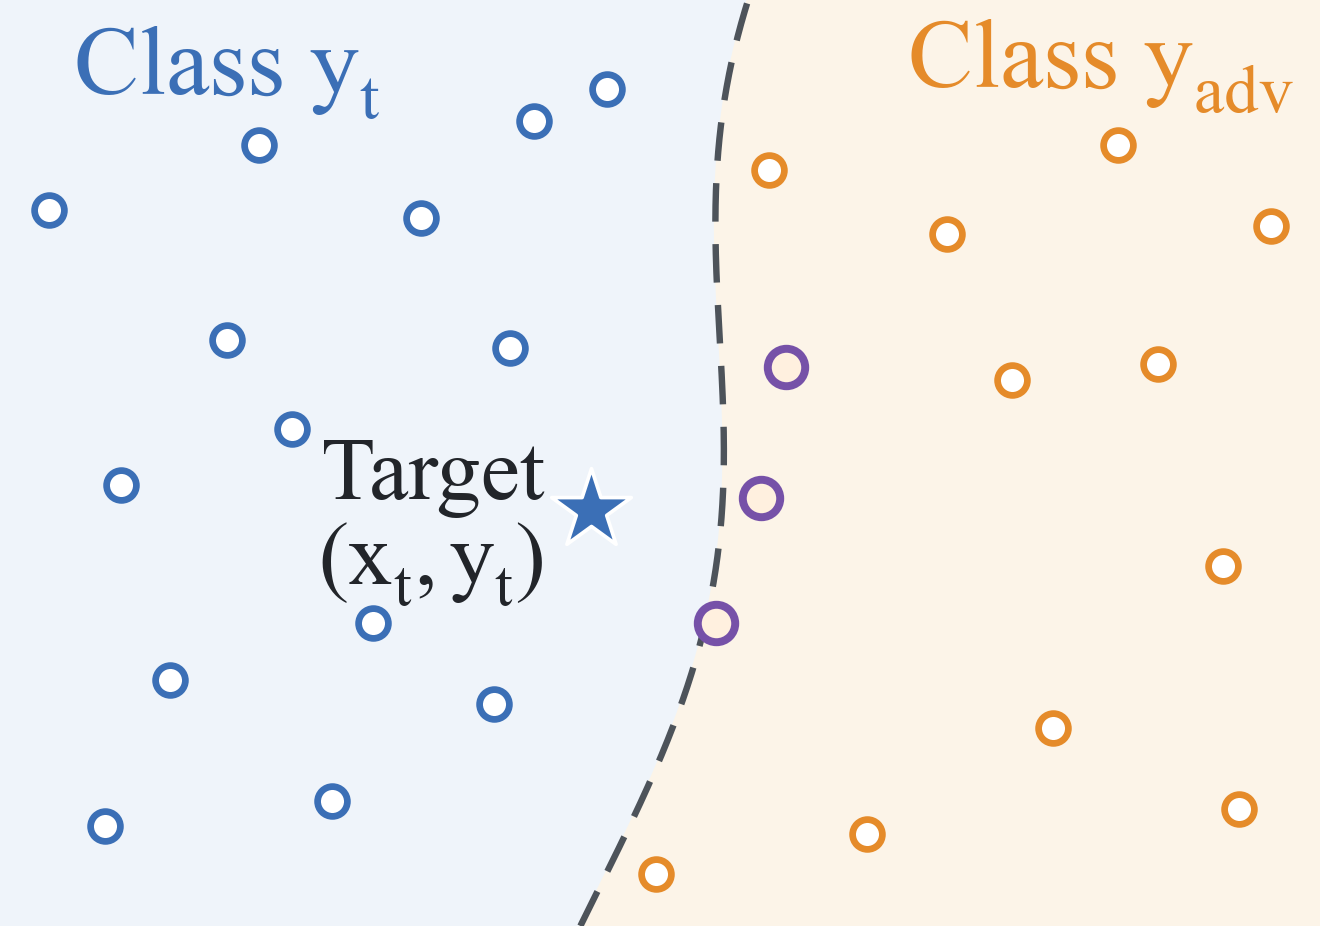

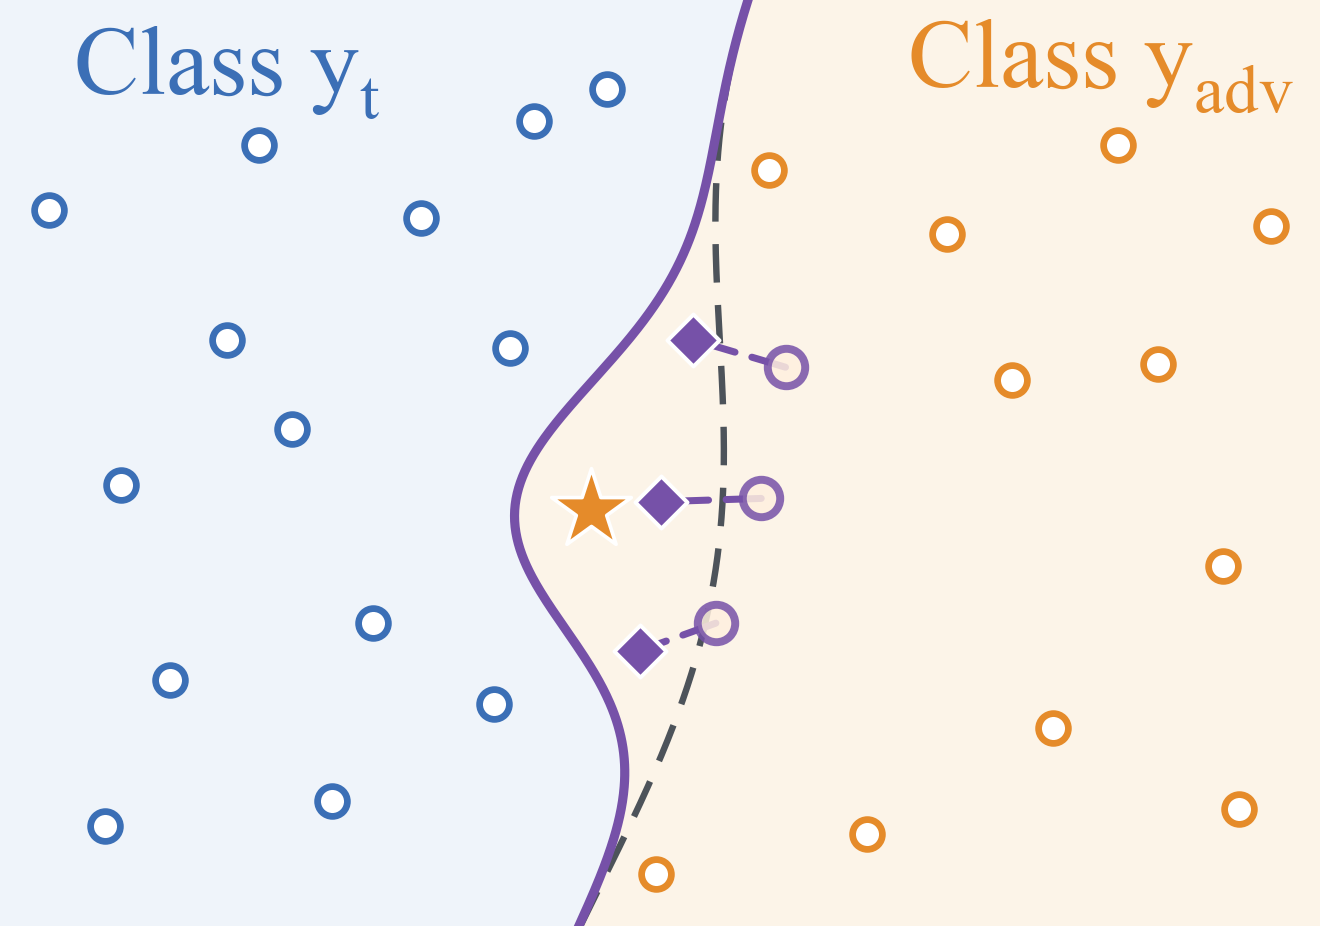

In [193]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Circle
from matplotlib.lines import Line2D


# =============================================================================
# MOST FREQUENTLY ADJUSTED SIZE CONTROLS
# =============================================================================

# -----------------------------
# Font sizes
# -----------------------------
FONT_SIZE = 24
CLASS_LABEL_SIZE = 32
TARGET_LABEL_SIZE = 29
AXES_TITLE_SIZE = 24

AXES_LABEL_SIZE = 24
LEGEND_FONT_SIZE = 16

# -----------------------------
# Marker sizes
# Matplotlib scatter sizes represent marker area.
# -----------------------------
CLEAN_POINT_SIZE = 95

LEFT_SELECTED_BASE_SIZE = 150
RIGHT_SELECTED_BASE_SIZE = 150

POISON_POINT_SIZE = 145
TARGET_POINT_SIZE = 750

# -----------------------------
# Perturbation trace visibility
# -----------------------------
TRACE_LINEWIDTH = 2.3
TRACE_LINESTYLE = (0, (5, 2.5))
TRACE_ALPHA = 1.0


# =============================================================================
# OTHER USER-CONTROLLABLE SETTINGS
# =============================================================================

# -----------------------------
# Output settings
# -----------------------------
OUTPUT_DIR = Path.cwd()

LEFT_OUTPUT_NAME = OUTPUT_DIR / "combinatorial_bilevel_poisoning_left"
RIGHT_OUTPUT_NAME = OUTPUT_DIR / "combinatorial_bilevel_poisoning_right"

SAVE_PNG = False
SAVE_PDF = True
SAVE_SVG = False

FIGURE_SIZE = (6, 4.5)
FIGURE_DPI = 220
PNG_DPI = 320

# Small amount of padding around exported files.
OUTPUT_PADDING = 0.01

# Use the entire available figure area.
FIGURE_LEFT_MARGIN = 0.0
FIGURE_RIGHT_MARGIN = 1.0
FIGURE_TOP_MARGIN = 1.0
FIGURE_BOTTOM_MARGIN = 0.0

# -----------------------------
# Axis controls
# Tighter limits trim unused space on the left, right, and bottom.
# -----------------------------
X_LIMITS = (0.40, 8.55)
Y_LIMITS = (0.48, 6.20)
AXIS_ASPECT = "equal"

# -----------------------------
# Font controls
# Times New Roman is used for both normal and mathematical text.
# -----------------------------
FONT_FAMILY = "Times New Roman"
MATH_FONT_SET = "custom"
MATH_TEXT_DEFAULT = "regular"

MATH_ROMAN_FONT = "Times New Roman"
MATH_ITALIC_FONT = "Times New Roman:italic"
MATH_BOLD_FONT = "Times New Roman:bold"

CLASS_LABEL_WEIGHT = "normal"
TARGET_LABEL_WEIGHT = "normal"

CLASS_LABEL_STYLE = "normal"
TARGET_LABEL_STYLE = "normal"

# Editable label text.
TRUE_CLASS_LABEL = r"Class $y_t$"
ADV_CLASS_LABEL = r"Class $y_{\mathrm{adv}}$"
TARGET_LABEL = "Target\n" + r"$(x_t, y_t)$"


# -----------------------------
# Colors
# -----------------------------
C_TRUE = "#3B6FB6"
C_ADV = "#E58B2A"
C_POISON = "#7651A8"
C_BOUNDARY = "#4D535A"
C_TEXT = "#22252A"

C_TRUE_BG = "#EFF4FA"
C_ADV_BG = "#FCF4E8"
C_SELECTED_BG = "#FFF0DF"

# Target colors.
LEFT_TARGET_COLOR = C_TRUE
RIGHT_TARGET_COLOR = C_ADV

# -----------------------------
# Shared clean-point styling
# -----------------------------
CLEAN_POINT_FACE_COLOR = "white"
CLEAN_POINT_LINEWIDTH = 2.2
CLEAN_POINT_ALPHA = 1.0

# -----------------------------
# Target styling
# -----------------------------
TARGET_INNER_EDGE_COLOR = "white"
TARGET_INNER_LINEWIDTH = 1.2
TARGET_OUTER_EDGE_COLOR = C_TEXT
TARGET_OUTER_LINEWIDTH = 0.0

# -----------------------------
# Selected-point styling
# -----------------------------
LEFT_SELECTED_BASE_LINEWIDTH = 2.6
LEFT_SELECTED_BASE_ALPHA = 1.0

RIGHT_SELECTED_BASE_LINEWIDTH = 2.6
RIGHT_SELECTED_BASE_ALPHA = 0.85

POISON_POINT_LINEWIDTH = 1.3
POISON_POINT_ALPHA = 1.0

# -----------------------------
# Decision-boundary styling
# -----------------------------
CLEAN_BOUNDARY_LINEWIDTH = 2.1
CLEAN_BOUNDARY_LINESTYLE = (0, (6, 3.5))

POISONED_BOUNDARY_LINEWIDTH = 3.0
POISONED_BOUNDARY_LINESTYLE = "-"

# -----------------------------
# Target-neighborhood styling
# -----------------------------
TARGET_NEIGHBORHOOD_RADIUS = 0
TARGET_NEIGHBORHOOD_LINEWIDTH = 0.1
TARGET_NEIGHBORHOOD_LINESTYLE = (0, (3, 3))
TARGET_NEIGHBORHOOD_ALPHA = 0.75

# -----------------------------
# Left target-label controls
# -----------------------------
LEFT_TARGET_LABEL_OFFSET_X = -0.29
LEFT_TARGET_LABEL_OFFSET_Y = -0.08
LEFT_TARGET_LABEL_HORIZONTAL_ALIGNMENT = "right"
LEFT_TARGET_LABEL_VERTICAL_ALIGNMENT = "center"
LEFT_TARGET_LABEL_LINE_SPACING = 1.05

# -----------------------------
# Class-label controls
# -----------------------------
TRUE_CLASS_LABEL_POSITION = (0.85, 5.75)
ADV_CLASS_LABEL_POSITION = (6, 5.79)

CLASS_LABEL_HORIZONTAL_ALIGNMENT = "left"
CLASS_LABEL_VERTICAL_ALIGNMENT = "center"

# -----------------------------
# Conceptual boundary controls
# -----------------------------
CLEAN_BOUNDARY_CENTER = 4.62
CLEAN_BOUNDARY_SLOPE = 0.22
CLEAN_BOUNDARY_WAVE_AMPLITUDE = 0.30
CLEAN_BOUNDARY_WAVE_FREQUENCY = 0.92
CLEAN_BOUNDARY_WAVE_SHIFT = 0.7

POISONED_BOUNDARY_SHIFT = 1.28
POISONED_BOUNDARY_CENTER_Y = 3.05
POISONED_BOUNDARY_WIDTH = 0.82


# =============================================================================
# MATPLOTLIB CONFIGURATION
# =============================================================================

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.serif": [FONT_FAMILY],
    "mathtext.fontset": MATH_FONT_SET,
    "mathtext.default": MATH_TEXT_DEFAULT,
    "mathtext.rm": MATH_ROMAN_FONT,
    "mathtext.it": MATH_ITALIC_FONT,
    "mathtext.bf": MATH_BOLD_FONT,
    "font.size": FONT_SIZE,
    "font.weight": "normal",
    "axes.titlesize": AXES_TITLE_SIZE,
    "axes.titleweight": "normal",
    "axes.labelsize": AXES_LABEL_SIZE,
    "axes.labelweight": "normal",
    "legend.fontsize": LEGEND_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# =============================================================================
# FEATURE-SPACE GEOMETRY
# =============================================================================

ygrid = np.linspace(Y_LIMITS[0], Y_LIMITS[1], 500)


def x_clean(y):
    return (
        CLEAN_BOUNDARY_CENTER
        + CLEAN_BOUNDARY_SLOPE * (y - 3.1)
        + CLEAN_BOUNDARY_WAVE_AMPLITUDE
        * np.sin(
            CLEAN_BOUNDARY_WAVE_FREQUENCY
            * (y - CLEAN_BOUNDARY_WAVE_SHIFT)
        )
    )


def x_poisoned(y):
    """Local boundary displacement created by the selected poisons."""
    return x_clean(y) - POISONED_BOUNDARY_SHIFT * np.exp(
        -0.5
        * (
            (y - POISONED_BOUNDARY_CENTER_Y)
            / POISONED_BOUNDARY_WIDTH
        ) ** 2
    )


# =============================================================================
# POINT LOCATIONS
# =============================================================================

true_pts = np.array([
    [1.05, 1.10],
    [1.45, 2.00],
    [1.15, 3.20],
    [1.80, 4.10],
    [2.45, 1.25],
    [2.70, 2.35],
    [2.20, 3.55],
    [3.00, 4.85],
    [3.45, 1.85],
    [3.55, 4.05],
    [2.00, 5.30],
    [3.70, 5.45],
    [4.15, 5.65],
    [0.70, 4.90],
])

adv_pts = np.array([
    [5.15, 5.15],
    [6.25, 4.75],
    [7.30, 5.30],
    [7.55, 3.95],
    [6.65, 3.85],
    [7.95, 2.70],
    [6.90, 1.70],
    [5.75, 1.05],
    [8.05, 1.20],
    [4.45, 0.80],
    [8.25, 4.80],
])

target = np.array([4.05, 3.05])

bases = np.array([
    [4.82, 2.35],
    [5.10, 3.12],
    [5.25, 3.93],
])

poisons = np.array([
    [4.35, 2.18],  # Lower point: farther left and slightly lower
    [4.48, 3.10],  # Middle point: farther left
    [4.68, 4.10],  # Upper point: farther left and slightly higher
])


# =============================================================================
# REUSABLE DRAWING FUNCTIONS
# =============================================================================

def configure_axis(ax):
    """Apply identical axis geometry to both figures."""
    ax.set_xlim(*X_LIMITS)
    ax.set_ylim(*Y_LIMITS)
    ax.set_aspect(AXIS_ASPECT, adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_class_labels(ax):
    """Draw identical class labels on both figures."""
    ax.text(
        *TRUE_CLASS_LABEL_POSITION,
        TRUE_CLASS_LABEL,
        color=C_TRUE,
        fontsize=CLASS_LABEL_SIZE,
        fontfamily=FONT_FAMILY,
        fontweight=CLASS_LABEL_WEIGHT,
        fontstyle=CLASS_LABEL_STYLE,
        ha=CLASS_LABEL_HORIZONTAL_ALIGNMENT,
        va=CLASS_LABEL_VERTICAL_ALIGNMENT,
        zorder=20,
    )

    ax.text(
        *ADV_CLASS_LABEL_POSITION,
        ADV_CLASS_LABEL,
        color=C_ADV,
        fontsize=CLASS_LABEL_SIZE,
        fontfamily=FONT_FAMILY,
        fontweight=CLASS_LABEL_WEIGHT,
        fontstyle=CLASS_LABEL_STYLE,
        ha=CLASS_LABEL_HORIZONTAL_ALIGNMENT,
        va=CLASS_LABEL_VERTICAL_ALIGNMENT,
        zorder=20,
    )


def draw_clean_points(ax):
    """Draw all ordinary samples using their class colors."""
    ax.scatter(
        true_pts[:, 0],
        true_pts[:, 1],
        s=CLEAN_POINT_SIZE,
        marker="o",
        facecolor=CLEAN_POINT_FACE_COLOR,
        edgecolor=C_TRUE,
        linewidth=CLEAN_POINT_LINEWIDTH,
        alpha=CLEAN_POINT_ALPHA,
        zorder=4,
    )

    ax.scatter(
        adv_pts[:, 0],
        adv_pts[:, 1],
        s=CLEAN_POINT_SIZE,
        marker="o",
        facecolor=CLEAN_POINT_FACE_COLOR,
        edgecolor=C_ADV,
        linewidth=CLEAN_POINT_LINEWIDTH,
        alpha=CLEAN_POINT_ALPHA,
        zorder=4,
    )


def draw_target(ax, target_color):
    """Draw the target star using the supplied class color."""
    ax.scatter(
        *target,
        s=TARGET_POINT_SIZE,
        marker="*",
        facecolor=target_color,
        edgecolor=TARGET_INNER_EDGE_COLOR,
        linewidth=TARGET_INNER_LINEWIDTH,
        zorder=9,
    )

    ax.scatter(
        *target,
        s=TARGET_POINT_SIZE,
        marker="*",
        facecolor="none",
        edgecolor=TARGET_OUTER_EDGE_COLOR,
        linewidth=TARGET_OUTER_LINEWIDTH,
        zorder=10,
    )


def finish_figure(fig):
    """Use the entire available figure canvas."""
    fig.subplots_adjust(
        left=FIGURE_LEFT_MARGIN,
        right=FIGURE_RIGHT_MARGIN,
        top=FIGURE_TOP_MARGIN,
        bottom=FIGURE_BOTTOM_MARGIN,
    )


def save_figure(fig, output_name):
    """Save each figure with minimal external padding."""
    output_name = str(output_name)

    if SAVE_PNG:
        fig.savefig(
            output_name + ".png",
            dpi=PNG_DPI,
            bbox_inches="tight",
            pad_inches=OUTPUT_PADDING,
            facecolor="white",
        )

    if SAVE_PDF:
        fig.savefig(
            output_name + ".pdf",
            bbox_inches="tight",
            pad_inches=OUTPUT_PADDING,
            facecolor="white",
        )

    if SAVE_SVG:
        fig.savefig(
            output_name + ".svg",
            bbox_inches="tight",
            pad_inches=OUTPUT_PADDING,
            facecolor="white",
        )


# =============================================================================
# LEFT FIGURE: SELECTED BASE SAMPLES
# =============================================================================

fig_left, ax_left = plt.subplots(
    figsize=FIGURE_SIZE,
    dpi=FIGURE_DPI,
    facecolor="white",
)

configure_axis(ax_left)

# Clean decision regions.
ax_left.fill_betweenx(
    ygrid,
    X_LIMITS[0],
    x_clean(ygrid),
    color=C_TRUE_BG,
    zorder=0,
)

ax_left.fill_betweenx(
    ygrid,
    x_clean(ygrid),
    X_LIMITS[1],
    color=C_ADV_BG,
    zorder=0,
)

# Clean decision boundary.
ax_left.plot(
    x_clean(ygrid),
    ygrid,
    linestyle=CLEAN_BOUNDARY_LINESTYLE,
    color=C_BOUNDARY,
    lw=CLEAN_BOUNDARY_LINEWIDTH,
    zorder=1,
)

# Target-similar neighborhood.
target_neighborhood = Circle(
    target,
    radius=TARGET_NEIGHBORHOOD_RADIUS,
    fill=False,
    edgecolor=C_POISON,
    linewidth=TARGET_NEIGHBORHOOD_LINEWIDTH,
    linestyle=TARGET_NEIGHBORHOOD_LINESTYLE,
    alpha=TARGET_NEIGHBORHOOD_ALPHA,
    zorder=2,
)
ax_left.add_patch(target_neighborhood)

# Ordinary samples.
draw_clean_points(ax_left)

# Selected base samples.
for base_point in bases:
    ax_left.scatter(
        *base_point,
        s=LEFT_SELECTED_BASE_SIZE,
        marker="o",
        facecolor=C_SELECTED_BG,
        edgecolor=C_POISON,
        linewidth=LEFT_SELECTED_BASE_LINEWIDTH,
        alpha=LEFT_SELECTED_BASE_ALPHA,
        zorder=7,
    )

# The target belongs to class y_t in the left figure.
draw_target(ax_left, LEFT_TARGET_COLOR)

# Two-line target label placed beside the star.
ax_left.text(
    target[0] + LEFT_TARGET_LABEL_OFFSET_X,
    target[1] + LEFT_TARGET_LABEL_OFFSET_Y,
    TARGET_LABEL,
    fontsize=TARGET_LABEL_SIZE,
    fontfamily=FONT_FAMILY,
    fontweight=TARGET_LABEL_WEIGHT,
    fontstyle=TARGET_LABEL_STYLE,
    color=C_TEXT,
    ha=LEFT_TARGET_LABEL_HORIZONTAL_ALIGNMENT,
    va=LEFT_TARGET_LABEL_VERTICAL_ALIGNMENT,
    linespacing=LEFT_TARGET_LABEL_LINE_SPACING,
    zorder=20,
)

draw_class_labels(ax_left)
finish_figure(fig_left)


# =============================================================================
# RIGHT FIGURE: POISONED RETRAINING AND BOUNDARY SHIFT
# =============================================================================

fig_right, ax_right = plt.subplots(
    figsize=FIGURE_SIZE,
    dpi=FIGURE_DPI,
    facecolor="white",
)

configure_axis(ax_right)

# Poisoned decision regions.
ax_right.fill_betweenx(
    ygrid,
    X_LIMITS[0],
    x_poisoned(ygrid),
    color=C_TRUE_BG,
    zorder=0,
)

ax_right.fill_betweenx(
    ygrid,
    x_poisoned(ygrid),
    X_LIMITS[1],
    color=C_ADV_BG,
    zorder=0,
)

# Original clean decision boundary.
ax_right.plot(
    x_clean(ygrid),
    ygrid,
    linestyle=CLEAN_BOUNDARY_LINESTYLE,
    color=C_BOUNDARY,
    lw=CLEAN_BOUNDARY_LINEWIDTH,
    zorder=2,
)

# Decision boundary after poisoned training.
ax_right.plot(
    x_poisoned(ygrid),
    ygrid,
    linestyle=POISONED_BOUNDARY_LINESTYLE,
    color=C_POISON,
    lw=POISONED_BOUNDARY_LINEWIDTH,
    zorder=3,
)

# Ordinary samples.
draw_clean_points(ax_right)

# Dashed traces from each clean base to its optimized poison.
for base_point, poison_point in zip(bases, poisons):
    ax_right.plot(
        [base_point[0], poison_point[0]],
        [base_point[1], poison_point[1]],
        color=C_POISON,
        lw=TRACE_LINEWIDTH,
        linestyle=TRACE_LINESTYLE,
        alpha=TRACE_ALPHA,
        solid_capstyle="round",
        dash_capstyle="round",
        zorder=6,
    )

    ax_right.scatter(
        *base_point,
        s=RIGHT_SELECTED_BASE_SIZE,
        marker="o",
        facecolor=C_SELECTED_BG,
        edgecolor=C_POISON,
        linewidth=RIGHT_SELECTED_BASE_LINEWIDTH,
        alpha=RIGHT_SELECTED_BASE_ALPHA,
        zorder=7,
    )

# Optimized poison points.
ax_right.scatter(
    poisons[:, 0],
    poisons[:, 1],
    s=POISON_POINT_SIZE,
    marker="D",
    facecolor=C_POISON,
    edgecolor="white",
    linewidth=POISON_POINT_LINEWIDTH,
    alpha=POISON_POINT_ALPHA,
    zorder=8,
)

# After the boundary shift, the target is predicted as class y_adv.
draw_target(ax_right, RIGHT_TARGET_COLOR)

draw_class_labels(ax_right)
finish_figure(fig_right)


# =============================================================================
# OPTIONAL LEGEND HANDLES
# =============================================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor=C_TRUE,
        markeredgewidth=CLEAN_POINT_LINEWIDTH,
        markersize=10,
        label=r"clean sample, class $y_t$",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor=C_ADV,
        markeredgewidth=CLEAN_POINT_LINEWIDTH,
        markersize=10,
        label=r"clean sample, class $y_{\mathrm{adv}}$",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=C_SELECTED_BG,
        markeredgecolor=C_POISON,
        markeredgewidth=2.0,
        markersize=11,
        label=r"selected base ($y_{\mathrm{adv}}$)",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor=C_POISON,
        markeredgecolor="white",
        markeredgewidth=1.0,
        markersize=10,
        label="optimized poison",
    ),
    Line2D(
        [0],
        [0],
        color=C_BOUNDARY,
        lw=CLEAN_BOUNDARY_LINEWIDTH,
        linestyle=CLEAN_BOUNDARY_LINESTYLE,
        label="clean boundary",
    ),
    Line2D(
        [0],
        [0],
        color=C_POISON,
        lw=POISONED_BOUNDARY_LINEWIDTH,
        label="boundary after poisoned training",
    ),
]


# =============================================================================
# SAVE BOTH FIGURES
# =============================================================================

save_figure(fig_left, LEFT_OUTPUT_NAME)
save_figure(fig_right, RIGHT_OUTPUT_NAME)

print(LEFT_OUTPUT_NAME)
print(RIGHT_OUTPUT_NAME)

# CTA

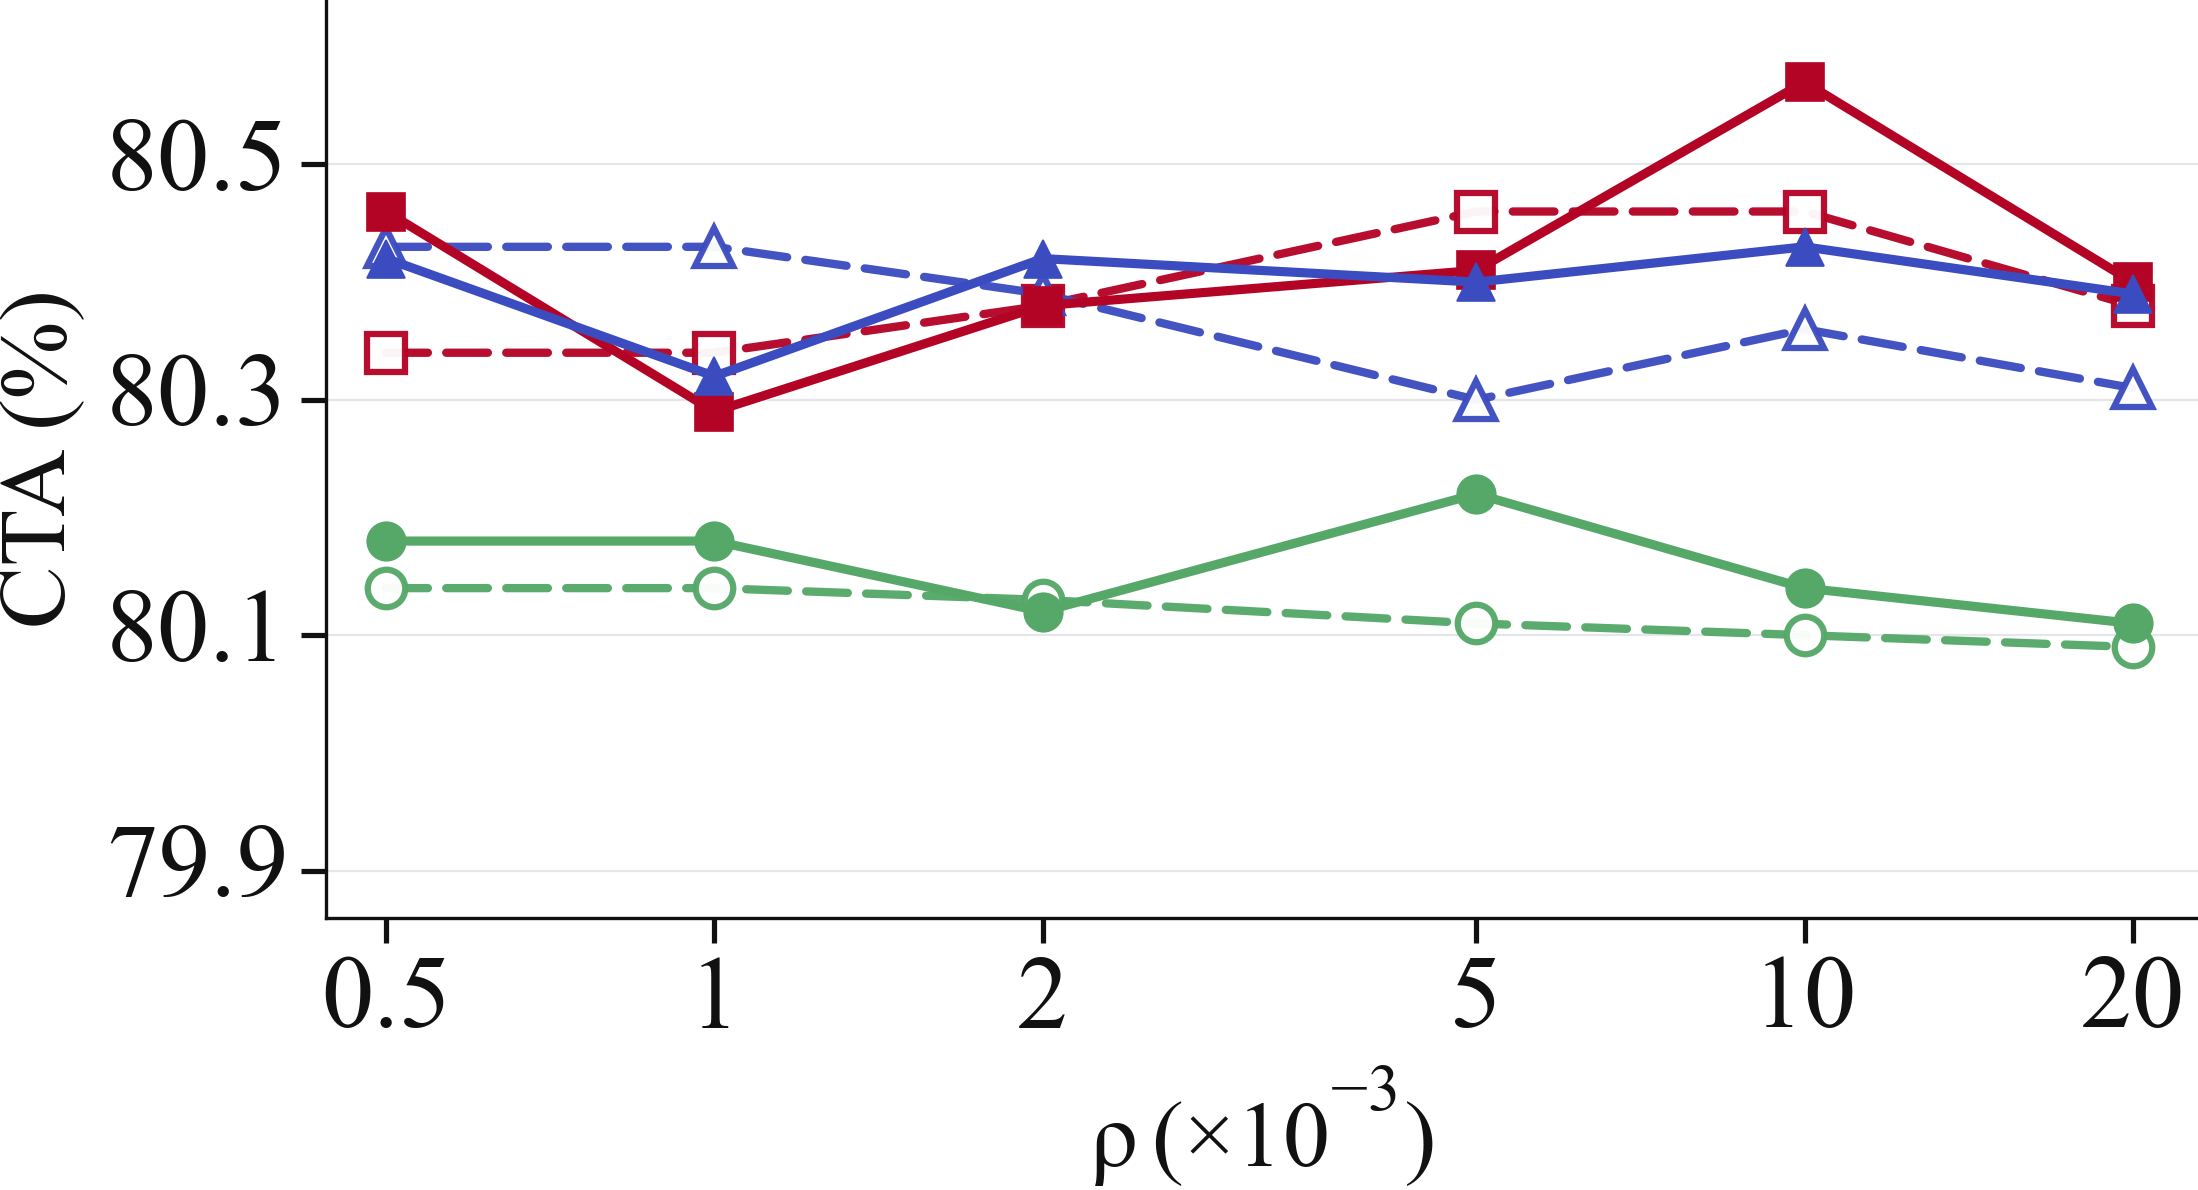

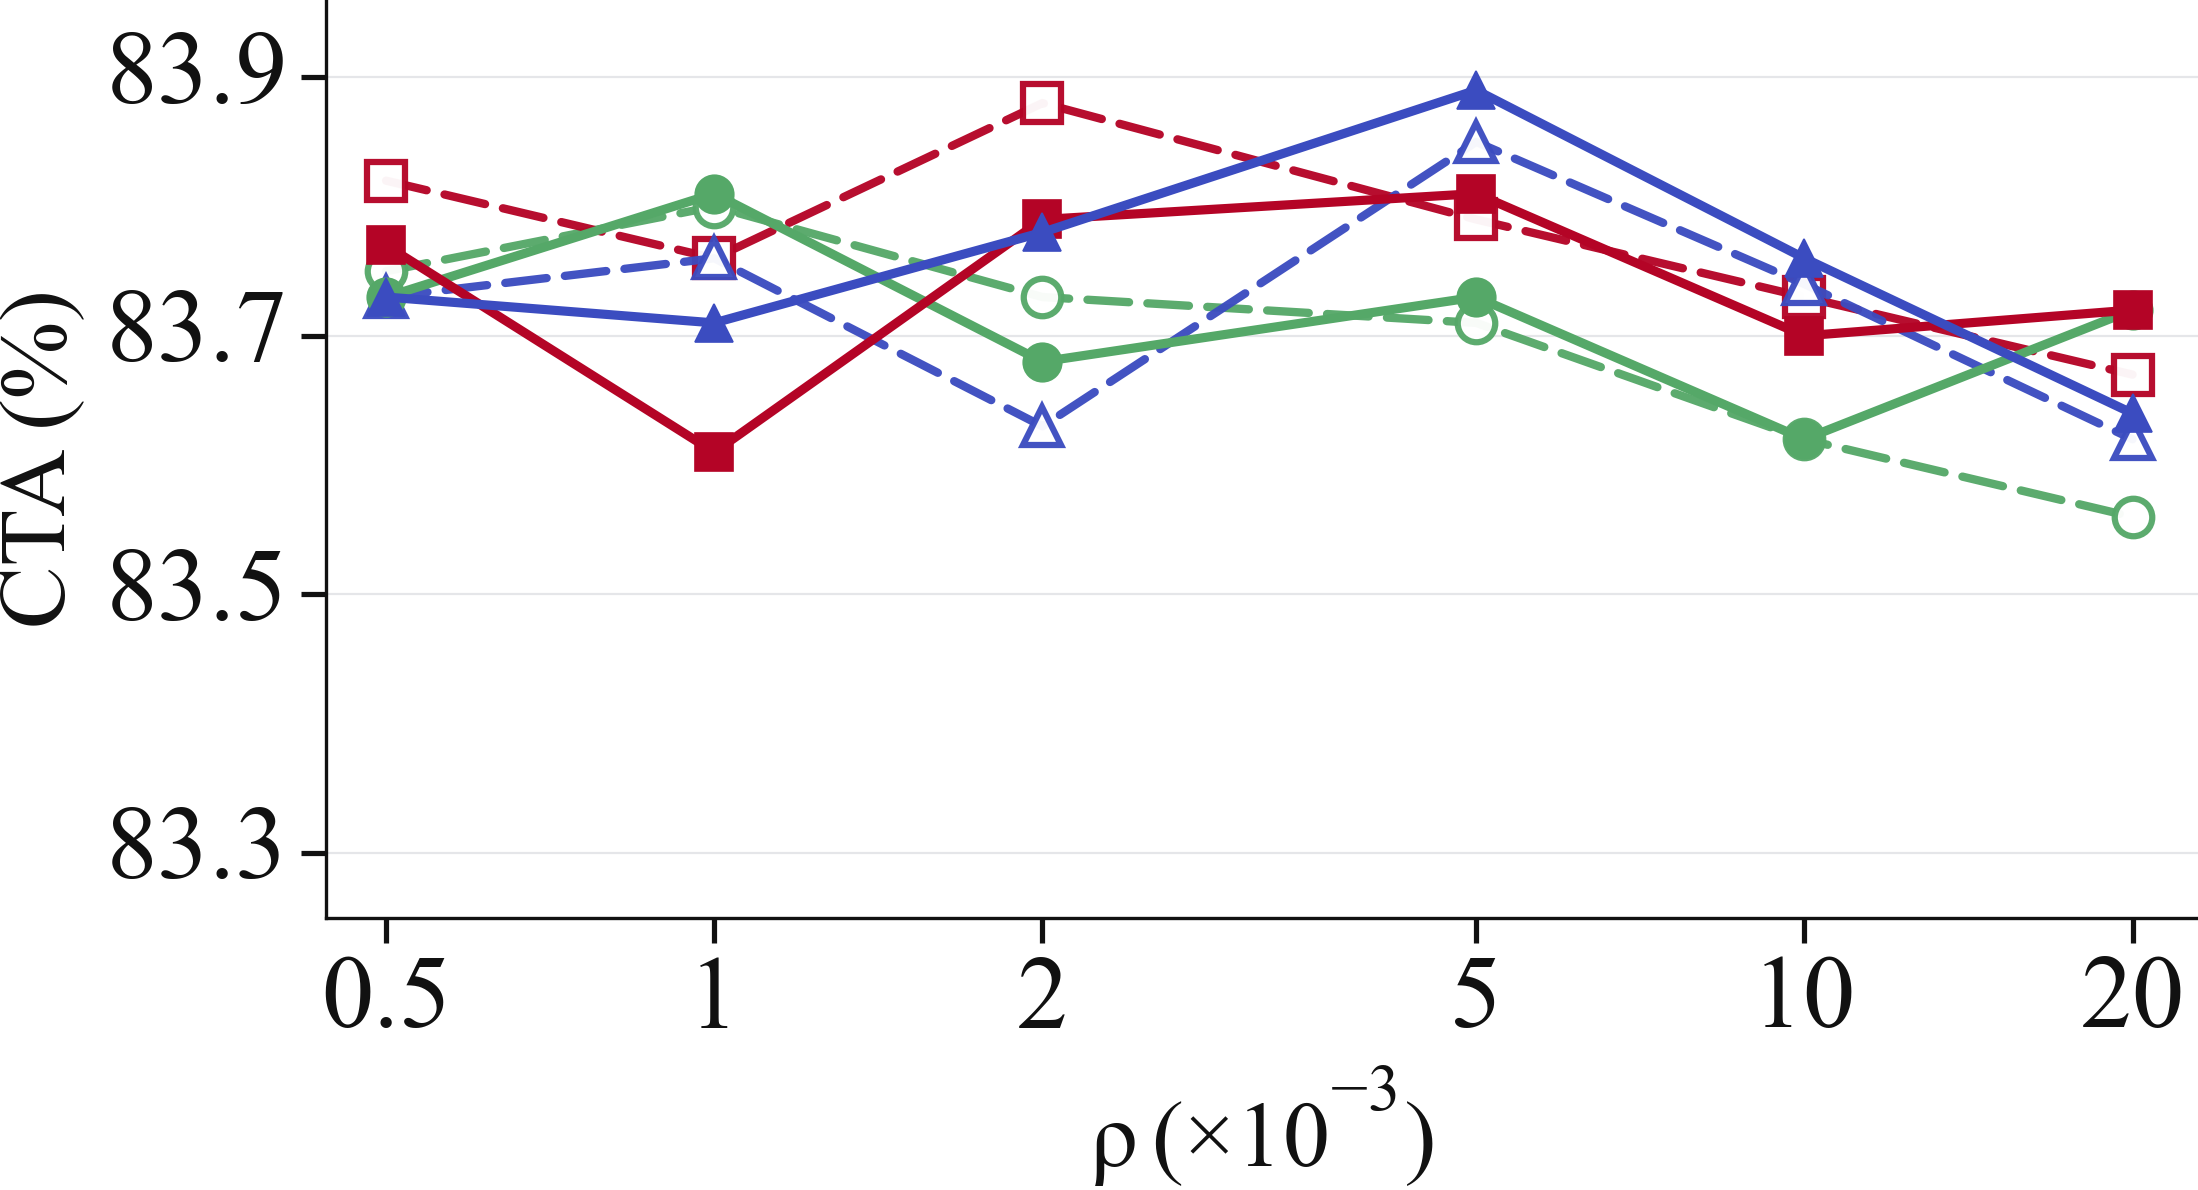

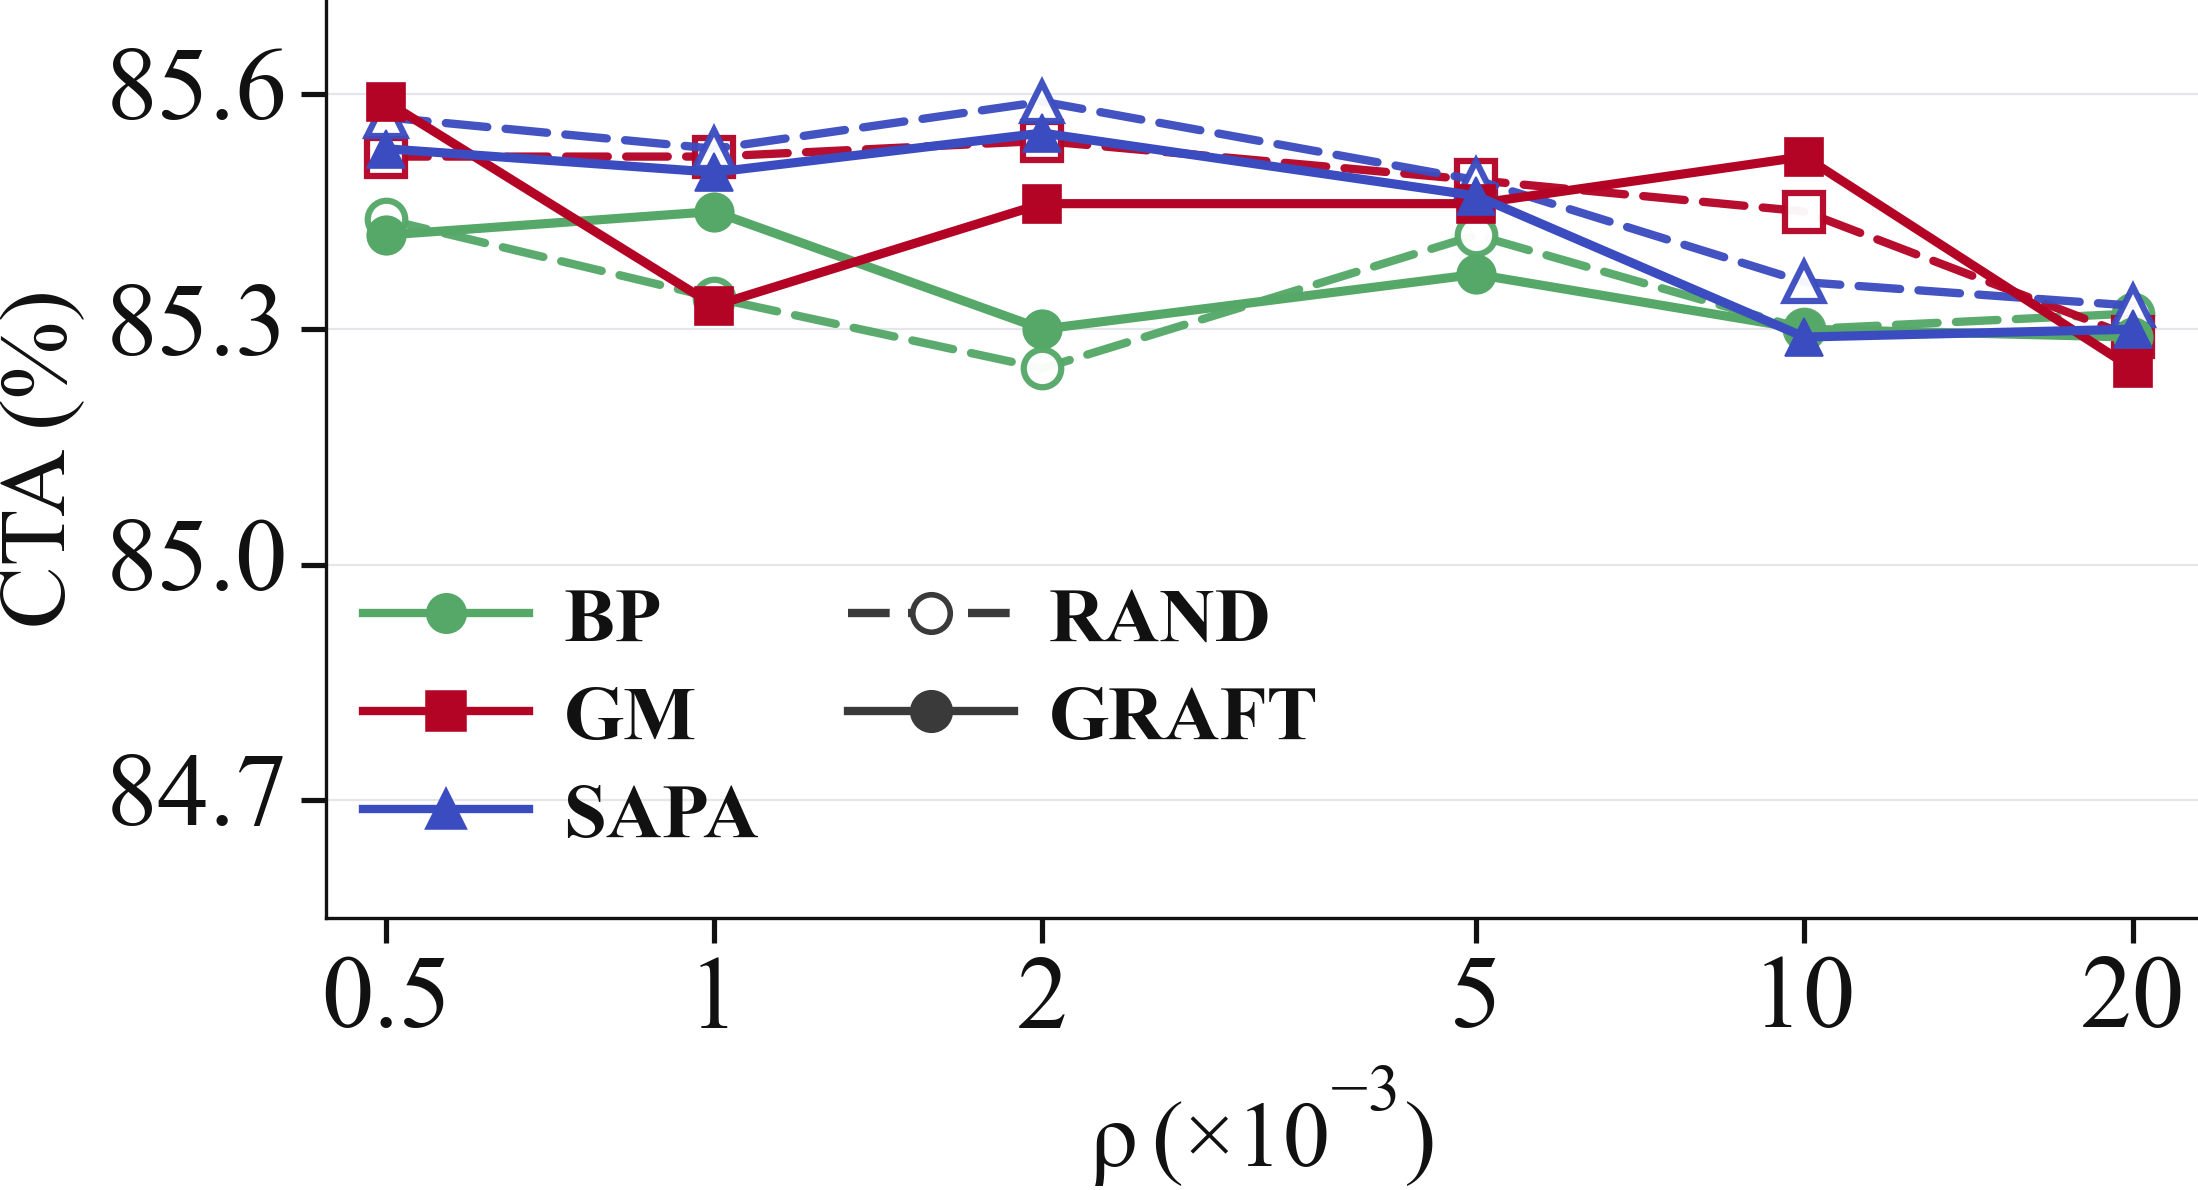

In [161]:
"""Jupyter-ready CTA sweep figures.

The cell creates one independent figure per model, plots dog--bird CTA only,
uses rho on the x-axis, and compares only Random with greedy.  Nothing is
hidden in a command-line interface or ``if __name__ == "__main__"`` block.

All presentation, layout, legend, curve, marker, axis, and export controls are
collected immediately below.  The data block begins after the controls.
"""

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, NullLocator, ScalarFormatter


# =============================================================================
# USER CONTROLS — edit values in this section only
# =============================================================================

# -----------------------------------------------------------------------------
# Content and ordering
# -----------------------------------------------------------------------------
RHO_VALUES = (0.5, 1, 2, 5, 10, 20)  # Units of 10^-3: 0.0005 through 0.02.
MODEL_ORDER = ("ConvNet", "ResNet20", "VGG13")
ATTACK_ORDER = ("BP", "GM", "SAPA")
SELECTION_ORDER = ("random", "greedy")
CLASS_PAIR = "dog--bird"                 # provenance only; never drawn

# A title is disabled by default so model/class-pair text can live in the caption.
SHOW_TITLES = False
TITLE_TEXT = {
    "ConvNet": "",
    "ResNet20": "",
    "VGG13": "",
}

# -----------------------------------------------------------------------------
# Figure canvas and axes placement
# -----------------------------------------------------------------------------
FIG_WIDTH = 13.5
FIG_HEIGHT = 8.5
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT)
FIGURE_DPI = 150                       # notebook display only
FIGURE_FACE_COLOR = "white"
AXES_FACE_COLOR = "white"
FIGURE_EDGE_COLOR = "white"
USE_CONSTRAINED_LAYOUT = False
USE_TIGHT_LAYOUT = False
TIGHT_LAYOUT_PAD = 0.40
SUBPLOT_LEFT = 0.070
SUBPLOT_RIGHT = 0.995
SUBPLOT_BOTTOM = 0.235
SUBPLOT_TOP = 0.955
SUBPLOT_WSPACE = 0.0                   # retained for easy future multi-axis use
SUBPLOT_HSPACE = 0.0

# -----------------------------------------------------------------------------
# Optional title styling (inactive while SHOW_TITLES is False)
# -----------------------------------------------------------------------------
TITLE_FONT_SIZE = 22
TITLE_FONT_WEIGHT = "bold"
TITLE_FONT_STYLE = "normal"
TITLE_FONT_COLOR = "#111111"
TITLE_ALIGNMENT = "center"
TITLE_PAD = 10
TITLE_Y = None                         # None lets Matplotlib choose

# -----------------------------------------------------------------------------
# Font family and global text rendering
# -----------------------------------------------------------------------------
FONT_FAMILY = "serif"
SERIF_FONT_FALLBACKS = (
    "Times New Roman",
    "Times",
    "Nimbus Roman No9 L",
    "DejaVu Serif",
)
SANS_SERIF_FONT_FALLBACKS = (
    "Arial",
    "Helvetica",
    "DejaVu Sans",
)
MONOSPACE_FONT_FALLBACKS = ("Courier New", "DejaVu Sans Mono")
MATH_FONTSET = "dejavuserif"
BASE_FONT_SIZE = 24
DEFAULT_TEXT_COLOR = "#111111"
PDF_FONT_TYPE = 42
PS_FONT_TYPE = 42
USE_TEX = False

# -----------------------------------------------------------------------------
# Axis labels
# -----------------------------------------------------------------------------
X_LABEL = r"$\rho\, (\times10^{-3})$"
Y_LABEL = "CTA (%)"
AXIS_LABEL_FONT_SIZE = 45

AXIS_LABEL_FONT_WEIGHT = "normal"
AXIS_LABEL_FONT_STYLE = "normal"
AXIS_LABEL_COLOR = "#111111"
X_LABEL_PAD = 7
Y_LABEL_PAD = 10
X_LABEL_HORIZONTAL_ALIGNMENT = "center"
Y_LABEL_VERTICAL_ALIGNMENT = "center"

# -----------------------------------------------------------------------------
# X axis
# -----------------------------------------------------------------------------
X_SCALE = "log"                        # "log" or "linear"
X_LOG_BASE = 2
X_LIMITS = (0.44, 23.0)
X_TICKS = RHO_VALUES
X_TICK_LABELS = tuple(str(value) for value in RHO_VALUES)
X_TICK_FORMATTER = "format"            # "scalar", "format", or None
X_TICK_FORMAT = "%g"
SHOW_X_MINOR_TICKS = False
X_MINOR_TICKS = ()
X_TICK_FONT_SIZE = 50
X_TICK_FONT_WEIGHT = "normal"
X_TICK_FONT_STYLE = "normal"
X_TICK_COLOR = "#111111"
X_TICK_ROTATION = 0
X_TICK_HORIZONTAL_ALIGNMENT = "center"
X_TICK_VERTICAL_ALIGNMENT = "top"

# -----------------------------------------------------------------------------
# Y axis — each independent model figure can have its own range and ticks
# -----------------------------------------------------------------------------
Y_LIMITS = {
    "ConvNet": (79.86, 80.64),
    "ResNet20": (83.25, 83.96),
    "VGG13": (84.55, 85.72),
}
Y_TICKS = {
    "ConvNet": (79.9, 80.1, 80.3, 80.5),
    "ResNet20": (83.3, 83.5, 83.7, 83.9),
    "VGG13": (84.7, 85.0, 85.3, 85.6),
}
Y_TICK_FORMAT = "%.1f"
SHOW_Y_MINOR_TICKS = False
Y_MINOR_TICKS = {
    "ConvNet": (),
    "ResNet20": (),
    "VGG13": (),
}
Y_TICK_FONT_SIZE = 50

Y_TICK_FONT_WEIGHT = "normal"
Y_TICK_FONT_STYLE = "normal"
Y_TICK_COLOR = "#111111"
Y_TICK_ROTATION = 0
Y_TICK_HORIZONTAL_ALIGNMENT = "right"
Y_TICK_VERTICAL_ALIGNMENT = "center"

# -----------------------------------------------------------------------------
# Tick marks and tick-label placement
# -----------------------------------------------------------------------------
TICK_DIRECTION = "out"
MAJOR_TICK_LENGTH = 12.0
MAJOR_TICK_WIDTH = 2.5
MINOR_TICK_LENGTH = 4.0
MINOR_TICK_WIDTH = 1.0
TICK_LABEL_PAD = 6.0
TICK_MARK_COLOR = "#111111"
SHOW_BOTTOM_TICKS = True
SHOW_TOP_TICKS = False
SHOW_LEFT_TICKS = True
SHOW_RIGHT_TICKS = False
SHOW_BOTTOM_TICK_LABELS = True
SHOW_TOP_TICK_LABELS = False
SHOW_LEFT_TICK_LABELS = True
SHOW_RIGHT_TICK_LABELS = False

# -----------------------------------------------------------------------------
# Spines
# -----------------------------------------------------------------------------
SPINE_VISIBILITY = {
    "left": True,
    "right": False,
    "bottom": True,
    "top": False,
}
SPINE_COLOR = "#111111"
SPINE_LINE_WIDTH = 1.6
SPINE_ZORDER = 10
SPINE_BOUNDS = {
    "left": None,
    "right": None,
    "bottom": None,
    "top": None,
}
SPINE_OUTWARD_POSITION = {
    "left": 0,
    "right": 0,
    "bottom": 0,
    "top": 0,
}

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------
SHOW_GRID = True
GRID_AXIS = "y"                         # "x", "y", or "both"
GRID_WHICH = "major"                    # "major", "minor", or "both"
GRID_COLOR = "#D5D8DC"
GRID_LINE_STYLE = "-"
GRID_LINE_WIDTH = 1.05
GRID_ALPHA = 0.62
GRID_ZORDER = 0
AXIS_BELOW_GRID = True

# -----------------------------------------------------------------------------
# Attack identity: color and marker shape
# Okabe--Ito-derived colors remain distinguishable in print and for common CVD.
# -----------------------------------------------------------------------------
# Keep this as None to use your custom ATTACK_COLORS mapping below, or replace
# None with one palette name from ATTACK_COLOR_PALETTE_OPTIONS.
SELECTED_ATTACK_COLOR_PALETTE = None

# Ten optional three-color sets.
ATTACK_COLOR_PALETTE_OPTIONS = {
    "option_01_okabe_ito": {
        "BP": "#0072B2", "GM": "#D55E00", "SAPA": "#009E73",
    },
    "option_02_tol_bright": {
        "BP": "#4477AA", "GM": "#EE6677", "SAPA": "#228833",
    },
    "option_03_vibrant": {
        "BP": "#0077BB", "GM": "#EE3377", "SAPA": "#EE7733",
    },
    "option_04_ibm": {
        "BP": "#648FFF", "GM": "#DC267F", "SAPA": "#FFB000",
    },
    "option_05_tableau": {
        "BP": "#4E79A7", "GM": "#E15759", "SAPA": "#59A14F",
    },
    "option_06_dark2": {
        "BP": "#1B9E77", "GM": "#D95F02", "SAPA": "#7570B3",
    },
    "option_07_cool_warm_gold": {
        "BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#F2C14E",
    },
    "option_08_earth": {
        "BP": "#264653", "GM": "#E76F51", "SAPA": "#2A9D8F",
    },
    "option_09_navy_rose_amber": {
        "BP": "#2F4B7C", "GM": "#D45087", "SAPA": "#FFA600",
    },
    "option_10_purple_red_green": {
        "BP": "#6A3D9A", "GM": "#E31A1C", "SAPA": "#33A02C",
    },
}


ATTACK_COLOR_PALETTE_OPTIONS.update({
    "option_11_blue_orange_green": {
        "BP": "#0057B8",
        "GM": "#E66100",
        "SAPA": "#008F5A",
    },
    "option_12_navy_magenta_gold": {
        "BP": "#173F5F",
        "GM": "#C2185B",
        "SAPA": "#E69F00",
    },
    "option_13_cyan_crimson_olive": {
        "BP": "#008CBA",
        "GM": "#C62828",
        "SAPA": "#657B00",
    },
    "option_14_purple_lime_scarlet": {
        "BP": "#6A1B9A",
        "GM": "#5B8C00",
        "SAPA": "#D32F2F",
    },
    "option_15_teal_amber_violet": {
        "BP": "#00796B",
        "GM": "#E68A00",
        "SAPA": "#7B2CBF",
    },
    "option_16_cobalt_coral_forest": {
        "BP": "#0047AB",
        "GM": "#E64B35",
        "SAPA": "#187A2F",
    },
    "option_17_indigo_tangerine_turquoise": {
        "BP": "#3F37C9",
        "GM": "#F26B0A",
        "SAPA": "#008C7A",
    },
    "option_18_charcoal_yellow_magenta": {
        "BP": "#2B2D42",
        "GM": "#E5A900",
        "SAPA": "#B5179E",
    },
    "option_19_sky_brick_darkgreen": {
        "BP": "#168AAD",
        "GM": "#B23A2B",
        "SAPA": "#386641",
    },
    "option_20_brown_cyan_purple": {
        "BP": "#8C4A2F",
        "GM": "#008FB3",
        "SAPA": "#7030A0",
    },
})


ATTACK_COLOR_PALETTE_OPTIONS.update({
    "option_21_science_journal": {
        "BP": "#0C5DA5",
        "GM": "#FF2C00",
        "SAPA": "#00B945",
    },
    "option_22_seaborn_muted": {
        "BP": "#4C72B0",
        "GM": "#DD8452",
        "SAPA": "#55A868",
    },
    "option_23_grayscale_safe": {
        "BP": "#2D3142",
        "SAPA": "#4F5D75",
        "GM": "#EF8354",
    },
    "option_24_indigo_cyan": {
        "BP": "#3A0CA3",
        "GM": "#F72585",
        "SAPA": "#4CC9F0",
    }
})

ATTACK_COLORS = {
    "BP": "#0072B2",                  # blue
    "GM": "#FF2C00",                  # vermilion
    "SAPA": "#009E73",                # bluish green
}
# ATTACK_COLORS={
# "BP": "#E5A900", "GM": "#0C5DA5", "SAPA": "#33A02C",}

# 1 — amber
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#F0A202"}

# 2 — golden yellow
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#E3B505"}

# 3 — muted gold
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#C99A00"}

# 4 — bright cyan
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#00A6D6"}

# 5 — dark cyan
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#008C95"}

# 6 — turquoise
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#00A087"}

# 7 — vivid orange
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#F28E2B"}

# 8 — dark mustard
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#9C8200"}

# 9 — cool slate
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#596775"}

# 10 — warm graphite
{"BP": "#3B4CC0", "GM": "#B40426", "SAPA": "#514A42"}

ATTACK_COLOR_PALETTE_OPTIONS.update({
    # 1. THE SLATE & SPICE: Extremely modern, heavily used in top-tier dataviz.
    # Dark charcoal for the baseline, with burnt orange and saffron for the attacks.
    "option_01_slate_spice": {
        "Random": "#264653",   # Deep Slate
        "greedy": "#E76F51",   # Burnt Orange
        "greedy_J": "#E9C46A", # Saffron Yellow
    },
    
    # 2. THE EDITORIAL: High contrast, aggressive but sophisticated.
    # Almost black baseline, deep carmine, and a sharp mustard accent.
    "option_02_editorial": {
        "Random": "#2B2D42",   # Gunmetal
        "greedy": "#D90429",   # Carmine
        "greedy_J": "#EDAE49", # Mustard
    },

    # 3. THE MIDNIGHT BERRY: Tech-forward but avoids pure blue/red.
    # Uses a dark midnight anchor, a rich berry/magenta, and a soft peach.
    "option_03_midnight_berry": {
        "Random": "#1D1E2C",   # Midnight Blue/Black
        "greedy": "#B8336A",   # Rich Berry
        "greedy_J": "#F4A261", # Warm Peach
    },

    # 4. THE PLUM & GOLD: Regal and highly colorblind safe.
    # Relies on the deep contrast between purple hues and bright gold.
    "option_04_plum_gold": {
        "Random": "#4A044E",   # Deep Plum
        "greedy": "#C77DFF",   # Bright Lilac
        "greedy_J": "#FFB703", # Pure Gold
    },

    # 5. THE DUSTY RETRO: Muted, aesthetic, looks like it was printed on matte paper.
    # Dark navy-grey anchor, terracotta, and vanilla.
    "option_05_dusty_retro": {
        "Random": "#3D405B",   # Navy-Slate
        "greedy": "#E07A5F",   # Terracotta
        "greedy_J": "#F2CC8F", # Vanilla/Sand
    }
})



ATTACK_COLORS = {
"BP": "#55A868", "GM": "#B40426", "SAPA": "#3B4CC0"}


if SELECTED_ATTACK_COLOR_PALETTE is not None:
    ATTACK_COLORS = dict(
        ATTACK_COLOR_PALETTE_OPTIONS[SELECTED_ATTACK_COLOR_PALETTE]
    )

ATTACK_MARKERS = {
    "BP": "o",
    "GM": "s",
    "SAPA": "^",
}
ATTACK_LABELS = {
    "BP": "BP",
    "GM": "GM",
    "SAPA": "SAPA",
}
ATTACK_ALPHA = {
    "BP": 1.0,
    "GM": 1.0,
    "SAPA": 1.0,
}
ATTACK_ZORDER_OFFSET = {
    "BP": 0,
    "GM": 0,
    "SAPA": 0,
}

# -----------------------------------------------------------------------------
# Selection identity: line style and marker fill
# Use a Matplotlib linestyle string or a dash tuple, e.g. (0, (5, 2)).
# Marker face can be "attack" to inherit its attack color, or any color string.
# -----------------------------------------------------------------------------
SELECTION_LINE_STYLES = {
    "random": (0, (5.0, 2.2)),
    "greedy": "-",
}
SELECTION_LABELS = {
    "random": "Random",
    "greedy": "greedy",
}

# Legend-only aliases. Change the values freely; data keys and plotting logic
# remain "random" and "greedy" regardless of what is displayed in the legend.
LEGEND_SELECTION_ALIASES = {
    "random": "RAND",
    "greedy": "GRAFT",
}
SELECTION_MARKER_FACES = {
    "random": "white",
    "greedy": "attack",
}
SELECTION_MARKER_EDGE_COLORS = {
    "random": "attack",
    "greedy": "attack",
}
SELECTION_LINE_WIDTHS = {
    "random": 4.0,
    "greedy": 4.4,
}
SELECTION_MARKER_SIZES = {
    "random": 18.0,
    "greedy": 18.5,
}
SELECTION_MARKER_EDGE_WIDTHS = {
    "random": 3.0,
    "greedy": 0.8,
}
SELECTION_ALPHA = {
    "random": 0.96,
    "greedy": 1.0,
}
SELECTION_ZORDER = {
    "random": 4,
    "greedy": 5,
}

# -----------------------------------------------------------------------------
# Curve and marker mechanics
# -----------------------------------------------------------------------------
LINE_DRAW_STYLE = "default"
LINE_SOLID_CAP_STYLE = "round"
LINE_DASH_CAP_STYLE = "round"
LINE_SOLID_JOIN_STYLE = "round"
LINE_DASH_JOIN_STYLE = "round"
MARK_EVERY = 1
CLIP_LINES_TO_AXES = True
ANTIALIASED_LINES = True
PICK_RADIUS = 5
MARKER_FILL_STYLE = "full"

# -----------------------------------------------------------------------------
# Legend — drawn only inside the third figure by default
# -----------------------------------------------------------------------------
SHOW_LEGEND = True
LEGEND_MODEL = "VGG13"
LEGEND_LOCATION = "lower center"
LEGEND_BBOX_TO_ANCHOR = (0.275, 0.018)  # axes coordinates; positive y is inside
LEGEND_BBOX_TRANSFORM = "axes"         # "axes" or "figure"
LEGEND_NUMBER_OF_COLUMNS = 2
LEGEND_MODE = None                     # use "expand" to stretch across the axes
LEGEND_ALIGNMENT = "center"
LEGEND_FONT_SIZE = 37
LEGEND_FONT_WEIGHT = "bold"
LEGEND_FONT_STYLE = "normal"
LEGEND_TEXT_COLOR = "#111111"
LEGEND_TITLE = None
LEGEND_TITLE_FONT_SIZE = 25
LEGEND_TITLE_FONT_WEIGHT = "bold"
LEGEND_FRAME_ON = True
LEGEND_FRAME_FACE_COLOR = "white"
LEGEND_FRAME_EDGE_COLOR = "#B8BDC3"
LEGEND_FRAME_ALPHA = 0.0
LEGEND_FRAME_LINE_WIDTH = 0.0
LEGEND_FANCY_BOX = True
LEGEND_SHADOW = False
LEGEND_BORDER_AXES_PAD = 0.25
LEGEND_BORDER_PAD = 0.38
LEGEND_LABEL_SPACING = 0.35
LEGEND_COLUMN_SPACING = 1.15
LEGEND_HANDLE_LENGTH = 2.15
LEGEND_HANDLE_HEIGHT = 0.75
LEGEND_HANDLE_TEXT_PAD = 0.45
LEGEND_MARKER_SCALE = 1.0
LEGEND_REVERSE_ORDER = False
LEGEND_ZORDER = 30

# Appearance of the five proxy handles: BP, GM, SAPA, Random, greedy.
LEGEND_ATTACK_HANDLE_LINE_STYLE = "-"
LEGEND_ATTACK_HANDLE_LINE_WIDTH = 4
LEGEND_ATTACK_HANDLE_MARKER_SIZE = 18.0
LEGEND_ATTACK_HANDLE_MARKER_FACE = "attack"
LEGEND_ATTACK_HANDLE_MARKER_EDGE_WIDTH = 1.7
LEGEND_SELECTION_HANDLE_COLOR = "#3A3A3A"
LEGEND_SELECTION_HANDLE_MARKER = "o"
LEGEND_SELECTION_HANDLE_MARKER_SIZE = 18.0
LEGEND_SELECTION_HANDLE_LINE_WIDTH = 4.0
LEGEND_SELECTION_HANDLE_MARKER_EDGE_WIDTH = 2.7

# -----------------------------------------------------------------------------
# Export and notebook display
# -----------------------------------------------------------------------------
SAVE_PDF = True
SAVE_PNG = False
SHOW_PLOTS = True
CLOSE_FIGURES_AFTER_SHOW = False
CREATE_OUTPUT_DIRECTORIES = True
# PDF_OUTPUT_DIRECTORY = Path("figures/pdf")
# PNG_OUTPUT_DIRECTORY = Path("figures/png")

PDF_OUTPUT_DIRECTORY = Path.cwd()
PNG_OUTPUT_DIRECTORY = Path.cwd()
OUTPUT_FILENAME_PREFIX = "cta"
OUTPUT_FILENAME_SUFFIX = ""
MODEL_FILENAME_SLUGS = {
    "ConvNet": "convnet",
    "ResNet20": "resnet20",
    "VGG13": "vgg13",
}
PDF_EXTENSION = ".pdf"
PNG_EXTENSION = ".png"
SAVE_DPI = 100
SAVE_BBOX_INCHES = "tight"             # None disables tight cropping
SAVE_PAD_INCHES = 0.0
SAVE_FACE_COLOR = "white"
SAVE_EDGE_COLOR = "white"
SAVE_TRANSPARENT = False
SAVE_ORIENTATION = "landscape"
SAVE_PDF_METADATA = {
    "Creator": "Matplotlib",
    "Title": "CTA poison-ratio sweep",
}
SAVE_PNG_METADATA = {
    "Software": "Matplotlib",
}

# -----------------------------------------------------------------------------
# Validation behavior
# -----------------------------------------------------------------------------
VALIDATE_DATA = True
REQUIRE_FINITE_VALUES = True
EXPECTED_NUMBER_OF_RHO_VALUES = 6


# =============================================================================
# DATA — dog--bird CTA (%) only; Random and greedy only
# =============================================================================

# Every series follows RHO_VALUES and contains six finite CTA measurements.
CTA = {
    "ConvNet": {
        ("BP", "random"): (80.14, 80.14, 80.13, 80.11, 80.10, 80.09),
        ("BP", "greedy"): (80.18, 80.18, 80.12, 80.22, 80.14, 80.11),
        ("GM", "random"): (80.34, 80.34, 80.38, 80.46, 80.46, 80.38),
        ("GM", "greedy"): (80.46, 80.29, 80.38, 80.41, 80.57, 80.40),
        ("SAPA", "random"): (80.43, 80.43, 80.39, 80.30, 80.36, 80.31),
        ("SAPA", "greedy"): (80.42, 80.32, 80.42, 80.40, 80.43, 80.39),
    },
    "ResNet20": {
        ("BP", "random"): (83.75, 83.80, 83.73, 83.71, 83.62, 83.56),
        ("BP", "greedy"): (83.73, 83.81, 83.68, 83.73, 83.62, 83.72),
        ("GM", "random"): (83.82, 83.76, 83.88, 83.79, 83.73, 83.67),
        ("GM", "greedy"): (83.77, 83.61, 83.79, 83.81, 83.70, 83.72),
        ("SAPA", "random"): (83.73, 83.76, 83.63, 83.85, 83.74, 83.62),
        ("SAPA", "greedy"): (83.73, 83.71, 83.78, 83.89, 83.76, 83.64),
    },
    "VGG13": {
        ("BP", "random"): (85.44, 85.34, 85.25, 85.42, 85.30, 85.32),
        ("BP", "greedy"): (85.42, 85.45, 85.30, 85.37, 85.30, 85.29),
        ("GM", "random"): (85.52, 85.52, 85.54, 85.49, 85.45, 85.29),
        ("GM", "greedy"): (85.59, 85.33, 85.46, 85.46, 85.52, 85.25),
        ("SAPA", "random"): (85.57, 85.53, 85.59, 85.49, 85.36, 85.33),
        ("SAPA", "greedy"): (85.53, 85.50, 85.55, 85.47, 85.29, 85.30),
    },
}


# =============================================================================
# PLOTTING IMPLEMENTATION — normally no edits are needed below this line
# =============================================================================

def _configure_matplotlib():
    """Apply the typography and export controls above."""
    mpl.rcParams.update(
        {
            "figure.facecolor": FIGURE_FACE_COLOR,
            "figure.edgecolor": FIGURE_EDGE_COLOR,
            "axes.facecolor": AXES_FACE_COLOR,
            "font.family": FONT_FAMILY,
            "font.serif": list(SERIF_FONT_FALLBACKS),
            "font.sans-serif": list(SANS_SERIF_FONT_FALLBACKS),
            "font.monospace": list(MONOSPACE_FONT_FALLBACKS),
            "font.size": BASE_FONT_SIZE,
            "text.color": DEFAULT_TEXT_COLOR,
            "text.usetex": USE_TEX,
            "mathtext.fontset": MATH_FONTSET,
            "axes.labelsize": AXIS_LABEL_FONT_SIZE,
            "axes.labelweight": AXIS_LABEL_FONT_WEIGHT,
            "axes.labelcolor": AXIS_LABEL_COLOR,
            "axes.titlesize": TITLE_FONT_SIZE,
            "axes.titleweight": TITLE_FONT_WEIGHT,
            "axes.titlecolor": TITLE_FONT_COLOR,
            "axes.edgecolor": SPINE_COLOR,
            "axes.linewidth": SPINE_LINE_WIDTH,
            "xtick.labelsize": X_TICK_FONT_SIZE,
            "xtick.color": X_TICK_COLOR,
            "ytick.labelsize": Y_TICK_FONT_SIZE,
            "ytick.color": Y_TICK_COLOR,
            "legend.fontsize": LEGEND_FONT_SIZE,
            "legend.frameon": LEGEND_FRAME_ON,
            "legend.fancybox": LEGEND_FANCY_BOX,
            "legend.shadow": LEGEND_SHADOW,
            "lines.antialiased": ANTIALIASED_LINES,
            "pdf.fonttype": PDF_FONT_TYPE,
            "ps.fonttype": PS_FONT_TYPE,
            "savefig.dpi": SAVE_DPI,
            "savefig.facecolor": SAVE_FACE_COLOR,
            "savefig.edgecolor": SAVE_EDGE_COLOR,
            "savefig.transparent": SAVE_TRANSPARENT,
            "savefig.bbox": SAVE_BBOX_INCHES,
            "savefig.pad_inches": SAVE_PAD_INCHES,
        }
    )


def _validate_data():
    """Fail early if a manually edited series no longer matches the x axis."""
    if len(RHO_VALUES) != EXPECTED_NUMBER_OF_RHO_VALUES:
        raise ValueError(
            "RHO_VALUES has "
            f"{len(RHO_VALUES)} entries; expected {EXPECTED_NUMBER_OF_RHO_VALUES}."
        )

    for model in MODEL_ORDER:
        if model not in CTA:
            raise KeyError(f"Missing model in CTA: {model}")
        for attack in ATTACK_ORDER:
            for selection in SELECTION_ORDER:
                key = (attack, selection)
                if key not in CTA[model]:
                    raise KeyError(f"Missing CTA series: {model}, {key}")
                values = CTA[model][key]
                if len(values) != len(RHO_VALUES):
                    raise ValueError(
                        f"{model} {key} has {len(values)} values; "
                        f"expected {len(RHO_VALUES)}."
                    )
                if REQUIRE_FINITE_VALUES:
                    for rho, value in zip(RHO_VALUES, values):
                        if not isinstance(value, (int, float)) or not math.isfinite(value):
                            raise ValueError(
                                f"Non-finite CTA value in {model} {key} "
                                f"at rho={rho}: {value}"
                            )


def _resolved_marker_color(setting, attack):
    """Translate the convenient 'attack' sentinel into the attack's color."""
    return ATTACK_COLORS[attack] if setting == "attack" else setting


def _style_spines(ax):
    for side, spine in ax.spines.items():
        spine.set_visible(SPINE_VISIBILITY[side])
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(SPINE_LINE_WIDTH)
        spine.set_zorder(SPINE_ZORDER)
        spine.set_position(("outward", SPINE_OUTWARD_POSITION[side]))
        if SPINE_BOUNDS[side] is not None:
            spine.set_bounds(*SPINE_BOUNDS[side])


def _style_ticks(ax, model):
    ax.tick_params(
        axis="both",
        which="major",
        direction=TICK_DIRECTION,
        length=MAJOR_TICK_LENGTH,
        width=MAJOR_TICK_WIDTH,
        pad=TICK_LABEL_PAD,
        color=TICK_MARK_COLOR,
        bottom=SHOW_BOTTOM_TICKS,
        top=SHOW_TOP_TICKS,
        left=SHOW_LEFT_TICKS,
        right=SHOW_RIGHT_TICKS,
        labelbottom=SHOW_BOTTOM_TICK_LABELS,
        labeltop=SHOW_TOP_TICK_LABELS,
        labelleft=SHOW_LEFT_TICK_LABELS,
        labelright=SHOW_RIGHT_TICK_LABELS,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        direction=TICK_DIRECTION,
        length=MINOR_TICK_LENGTH,
        width=MINOR_TICK_WIDTH,
        color=TICK_MARK_COLOR,
    )
    ax.tick_params(axis="x", labelsize=X_TICK_FONT_SIZE, labelcolor=X_TICK_COLOR)
    ax.tick_params(axis="y", labelsize=Y_TICK_FONT_SIZE, labelcolor=Y_TICK_COLOR)

    for label in ax.get_xticklabels():
        label.set_fontweight(X_TICK_FONT_WEIGHT)
        label.set_fontstyle(X_TICK_FONT_STYLE)
        label.set_rotation(X_TICK_ROTATION)
        label.set_horizontalalignment(X_TICK_HORIZONTAL_ALIGNMENT)
        label.set_verticalalignment(X_TICK_VERTICAL_ALIGNMENT)

    for label in ax.get_yticklabels():
        label.set_fontweight(Y_TICK_FONT_WEIGHT)
        label.set_fontstyle(Y_TICK_FONT_STYLE)
        label.set_rotation(Y_TICK_ROTATION)
        label.set_horizontalalignment(Y_TICK_HORIZONTAL_ALIGNMENT)
        label.set_verticalalignment(Y_TICK_VERTICAL_ALIGNMENT)

    if SHOW_X_MINOR_TICKS:
        ax.set_xticks(X_MINOR_TICKS, minor=True)
    else:
        ax.xaxis.set_minor_locator(NullLocator())

    if SHOW_Y_MINOR_TICKS:
        ax.set_yticks(Y_MINOR_TICKS[model], minor=True)
    else:
        ax.yaxis.set_minor_locator(NullLocator())


def _legend_handles():
    handles = []

    for attack in ATTACK_ORDER:
        attack_face = _resolved_marker_color(
            LEGEND_ATTACK_HANDLE_MARKER_FACE,
            attack,
        )
        handles.append(
            Line2D(
                [],
                [],
                label=ATTACK_LABELS[attack],
                color=ATTACK_COLORS[attack],
                linestyle=LEGEND_ATTACK_HANDLE_LINE_STYLE,
                linewidth=LEGEND_ATTACK_HANDLE_LINE_WIDTH,
                marker=ATTACK_MARKERS[attack],
                markersize=LEGEND_ATTACK_HANDLE_MARKER_SIZE,
                markerfacecolor=attack_face,
                markeredgecolor=ATTACK_COLORS[attack],
                markeredgewidth=LEGEND_ATTACK_HANDLE_MARKER_EDGE_WIDTH,
            )
        )

    for selection in SELECTION_ORDER:
        neutral_face = SELECTION_MARKER_FACES[selection]
        if neutral_face == "attack":
            neutral_face = LEGEND_SELECTION_HANDLE_COLOR
        neutral_edge = SELECTION_MARKER_EDGE_COLORS[selection]
        if neutral_edge == "attack":
            neutral_edge = LEGEND_SELECTION_HANDLE_COLOR
        handles.append(
            Line2D(
                [],
                [],
                label=LEGEND_SELECTION_ALIASES[selection],
                color=LEGEND_SELECTION_HANDLE_COLOR,
                linestyle=SELECTION_LINE_STYLES[selection],
                linewidth=LEGEND_SELECTION_HANDLE_LINE_WIDTH,
                marker=LEGEND_SELECTION_HANDLE_MARKER,
                markersize=LEGEND_SELECTION_HANDLE_MARKER_SIZE,
                markerfacecolor=neutral_face,
                markeredgecolor=neutral_edge,
                markeredgewidth=LEGEND_SELECTION_HANDLE_MARKER_EDGE_WIDTH,
            )
        )

    return list(reversed(handles)) if LEGEND_REVERSE_ORDER else handles


def _add_legend(fig, ax):
    bbox_transform = ax.transAxes if LEGEND_BBOX_TRANSFORM == "axes" else fig.transFigure
    legend = ax.legend(
        handles=_legend_handles(),
        loc=LEGEND_LOCATION,
        bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
        bbox_transform=bbox_transform,
        ncol=LEGEND_NUMBER_OF_COLUMNS,
        mode=LEGEND_MODE,
        alignment=LEGEND_ALIGNMENT,
        title=LEGEND_TITLE,
        frameon=LEGEND_FRAME_ON,
        fancybox=LEGEND_FANCY_BOX,
        shadow=LEGEND_SHADOW,
        facecolor=LEGEND_FRAME_FACE_COLOR,
        edgecolor=LEGEND_FRAME_EDGE_COLOR,
        framealpha=LEGEND_FRAME_ALPHA,
        borderaxespad=LEGEND_BORDER_AXES_PAD,
        borderpad=LEGEND_BORDER_PAD,
        labelspacing=LEGEND_LABEL_SPACING,
        columnspacing=LEGEND_COLUMN_SPACING,
        handlelength=LEGEND_HANDLE_LENGTH,
        handleheight=LEGEND_HANDLE_HEIGHT,
        handletextpad=LEGEND_HANDLE_TEXT_PAD,
        markerscale=LEGEND_MARKER_SCALE,
        prop={
            "size": LEGEND_FONT_SIZE,
            "weight": LEGEND_FONT_WEIGHT,
            "style": LEGEND_FONT_STYLE,
        },
    )
    legend.set_zorder(LEGEND_ZORDER)
    legend.get_frame().set_linewidth(LEGEND_FRAME_LINE_WIDTH)
    for text_item in legend.get_texts():
        text_item.set_color(LEGEND_TEXT_COLOR)
    if legend.get_title() is not None:
        legend.get_title().set_fontsize(LEGEND_TITLE_FONT_SIZE)
        legend.get_title().set_fontweight(LEGEND_TITLE_FONT_WEIGHT)
        legend.get_title().set_color(LEGEND_TEXT_COLOR)
    return legend


def _output_stem(model):
    suffix = f"_{OUTPUT_FILENAME_SUFFIX}" if OUTPUT_FILENAME_SUFFIX else ""
    return f"{OUTPUT_FILENAME_PREFIX}_{MODEL_FILENAME_SLUGS[model]}{suffix}"


def _save_figure(fig, model):
    stem = _output_stem(model)
    common = {
        "dpi": SAVE_DPI,
        "bbox_inches": SAVE_BBOX_INCHES,
        "pad_inches": SAVE_PAD_INCHES,
        "facecolor": SAVE_FACE_COLOR,
        "edgecolor": SAVE_EDGE_COLOR,
        "transparent": SAVE_TRANSPARENT,
        "orientation": SAVE_ORIENTATION,
    }

    if SAVE_PDF:
        if CREATE_OUTPUT_DIRECTORIES:
            PDF_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            PDF_OUTPUT_DIRECTORY / f"{stem}{PDF_EXTENSION}",
            metadata=SAVE_PDF_METADATA,
            **common,
        )

    if SAVE_PNG:
        if CREATE_OUTPUT_DIRECTORIES:
            PNG_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            PNG_OUTPUT_DIRECTORY / f"{stem}{PNG_EXTENSION}",
            metadata=SAVE_PNG_METADATA,
            **common,
        )


def plot_cta_figures():
    """Create and optionally save three separate figures; return both mappings."""
    if VALIDATE_DATA:
        _validate_data()
    _configure_matplotlib()

    figures = {}
    axes = {}

    for model in MODEL_ORDER:
        fig, ax = plt.subplots(
            figsize=FIG_SIZE,
            dpi=FIGURE_DPI,
            constrained_layout=USE_CONSTRAINED_LAYOUT,
            facecolor=FIGURE_FACE_COLOR,
            edgecolor=FIGURE_EDGE_COLOR,
        )
        ax.set_facecolor(AXES_FACE_COLOR)

        for attack in ATTACK_ORDER:
            for selection in SELECTION_ORDER:
                marker_face = _resolved_marker_color(
                    SELECTION_MARKER_FACES[selection],
                    attack,
                )
                marker_edge = _resolved_marker_color(
                    SELECTION_MARKER_EDGE_COLORS[selection],
                    attack,
                )
                ax.plot(
                    RHO_VALUES,
                    CTA[model][(attack, selection)],
                    color=ATTACK_COLORS[attack],
                    linestyle=SELECTION_LINE_STYLES[selection],
                    linewidth=SELECTION_LINE_WIDTHS[selection],
                    alpha=ATTACK_ALPHA[attack] * SELECTION_ALPHA[selection],
                    marker=ATTACK_MARKERS[attack],
                    markersize=SELECTION_MARKER_SIZES[selection],
                    markerfacecolor=marker_face,
                    markeredgecolor=marker_edge,
                    markeredgewidth=SELECTION_MARKER_EDGE_WIDTHS[selection],
                    fillstyle=MARKER_FILL_STYLE,
                    drawstyle=LINE_DRAW_STYLE,
                    solid_capstyle=LINE_SOLID_CAP_STYLE,
                    dash_capstyle=LINE_DASH_CAP_STYLE,
                    solid_joinstyle=LINE_SOLID_JOIN_STYLE,
                    dash_joinstyle=LINE_DASH_JOIN_STYLE,
                    markevery=MARK_EVERY,
                    clip_on=CLIP_LINES_TO_AXES,
                    antialiased=ANTIALIASED_LINES,
                    picker=PICK_RADIUS,
                    zorder=(
                        SELECTION_ZORDER[selection]
                        + ATTACK_ZORDER_OFFSET[attack]
                    ),
                )

        if X_SCALE == "log":
            ax.set_xscale("log", base=X_LOG_BASE)
        else:
            ax.set_xscale(X_SCALE)
        ax.set_xlim(*X_LIMITS)
        ax.set_xticks(X_TICKS)
        ax.set_xticklabels(X_TICK_LABELS)
        if X_TICK_FORMATTER == "scalar":
            ax.xaxis.set_major_formatter(ScalarFormatter())
        elif X_TICK_FORMATTER == "format":
            ax.xaxis.set_major_formatter(FormatStrFormatter(X_TICK_FORMAT))

        ax.set_ylim(*Y_LIMITS[model])
        ax.set_yticks(Y_TICKS[model])
        ax.yaxis.set_major_formatter(FormatStrFormatter(Y_TICK_FORMAT))

        ax.set_xlabel(
            X_LABEL,
            fontsize=AXIS_LABEL_FONT_SIZE,
            fontweight=AXIS_LABEL_FONT_WEIGHT,
            fontstyle=AXIS_LABEL_FONT_STYLE,
            color=AXIS_LABEL_COLOR,
            labelpad=X_LABEL_PAD,
            loc=X_LABEL_HORIZONTAL_ALIGNMENT,
        )
        ax.set_ylabel(
            Y_LABEL,
            fontsize=AXIS_LABEL_FONT_SIZE,
            fontweight=AXIS_LABEL_FONT_WEIGHT,
            fontstyle=AXIS_LABEL_FONT_STYLE,
            color=AXIS_LABEL_COLOR,
            labelpad=Y_LABEL_PAD,
            loc=Y_LABEL_VERTICAL_ALIGNMENT,
        )

        if SHOW_TITLES:
            title_kwargs = {
                "fontsize": TITLE_FONT_SIZE,
                "fontweight": TITLE_FONT_WEIGHT,
                "fontstyle": TITLE_FONT_STYLE,
                "color": TITLE_FONT_COLOR,
                "loc": TITLE_ALIGNMENT,
                "pad": TITLE_PAD,
            }
            if TITLE_Y is not None:
                title_kwargs["y"] = TITLE_Y
            ax.set_title(TITLE_TEXT[model], **title_kwargs)

        if SHOW_GRID:
            ax.grid(
                visible=True,
                which=GRID_WHICH,
                axis=GRID_AXIS,
                color=GRID_COLOR,
                linestyle=GRID_LINE_STYLE,
                linewidth=GRID_LINE_WIDTH,
                alpha=GRID_ALPHA,
                zorder=GRID_ZORDER,
            )
        else:
            ax.grid(False)
        ax.set_axisbelow(AXIS_BELOW_GRID)

        _style_spines(ax)
        _style_ticks(ax, model)

        fig.subplots_adjust(
            left=SUBPLOT_LEFT,
            right=SUBPLOT_RIGHT,
            bottom=SUBPLOT_BOTTOM,
            top=SUBPLOT_TOP,
            wspace=SUBPLOT_WSPACE,
            hspace=SUBPLOT_HSPACE,
        )
        if USE_TIGHT_LAYOUT:
            fig.tight_layout(pad=TIGHT_LAYOUT_PAD)

        if SHOW_LEGEND and model == LEGEND_MODEL:
            _add_legend(fig, ax)

        figures[model] = fig
        axes[model] = ax
        _save_figure(fig, model)

    if SHOW_PLOTS:
        plt.show()
    if CLOSE_FIGURES_AFTER_SHOW:
        for figure in figures.values():
            plt.close(figure)

    return figures, axes


# Jupyter execution line: creates three independent figures and exposes their
# objects for later notebook edits.  There is deliberately no main/CLI wrapper.
figures, axes = plot_cta_figures()


# end